In [1]:
import sys

print("Python executable:")
print(sys.executable)

try:
    import tslearn
    print("tslearn version:", tslearn.__version__)
except ModuleNotFoundError:
    raise ModuleNotFoundError(
        "\nTSLEARN IS NOT INSTALLED IN THIS JUPYTER KERNEL.\n"
        "Select: Kernel -> Change Kernel -> Python (inflation_project)\n"
        "Then install tslearn in that environment."
    )

Python executable:
C:\Users\Aarjav\anaconda3\envs\inflation_project\python.exe
tslearn version: 0.9.0


In [2]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics import silhouette_score

from tslearn.clustering import TimeSeriesKMeans
from tslearn.preprocessing import TimeSeriesScalerMeanVariance
from tslearn.metrics import cdist_dtw

print("All required libraries imported successfully.")

C:\Users\Aarjav\anaconda3\envs\inflation_project\Lib\site-packages\tslearn\bases\bases.py:16: UserWarning: h5py not installed, hdf5 features will not be supported.
Install h5py to use hdf5 features: http://docs.h5py.org/
  warn(h5py_msg)


All required libraries imported successfully.


In [3]:


wb = pd.read_csv("worldbank_inflation_model_ready.csv")
meta = pd.read_csv("META_1.csv")

print("World Bank shape:", wb.shape)
print("Metadata shape:", meta.shape)

World Bank shape: (240, 70)
Metadata shape: (264, 5)


In [4]:
print("World Bank columns:")
print(wb.columns.tolist())

print("\nMetadata columns:")
print(meta.columns.tolist())

World Bank columns:
['Country Name', 'Country Code', 'Indicator Name', 'Indicator Code', '1960', '1961', '1962', '1963', '1964', '1965', '1966', '1967', '1968', '1969', '1970', '1971', '1972', '1973', '1974', '1975', '1976', '1977', '1978', '1979', '1980', '1981', '1982', '1983', '1984', '1985', '1986', '1987', '1988', '1989', '1990', '1991', '1992', '1993', '1994', '1995', '1996', '1997', '1998', '1999', '2000', '2001', '2002', '2003', '2004', '2005', '2006', '2007', '2008', '2009', '2010', '2011', '2012', '2013', '2014', '2015', '2016', '2017', '2018', '2019', '2020', '2021', '2022', '2023', '2024', '2025']

Metadata columns:
['Country Code', 'Region', 'IncomeGroup', 'SpecialNotes', 'TableName']


In [5]:
year_columns = [
    str(col)
    for col in wb.columns
    if str(col).isdigit() and 1900 <= int(col) <= 2100
]

year_columns = sorted(
    year_columns,
    key=int
)

print("First year:", year_columns[0])
print("Last year:", year_columns[-1])
print("Number of years:", len(year_columns))

First year: 1960
Last year: 2025
Number of years: 66


In [6]:
START_YEAR = 1960
END_YEAR = 2025

CLUSTER_YEARS = [
    str(year)
    for year in range(START_YEAR, END_YEAR + 1)
]

missing_year_columns = [
    year
    for year in CLUSTER_YEARS
    if year not in wb.columns
]

if missing_year_columns:
    raise ValueError(
        f"Missing required year columns: {missing_year_columns}"
    )

print(f"Clustering period: {START_YEAR}–{END_YEAR}")
print("Number of yearly observations:", len(CLUSTER_YEARS))

Clustering period: 1960–2025
Number of yearly observations: 66


In [7]:
meta_clean = meta[
    ["Country Code", "Region"]
].drop_duplicates(
    subset=["Country Code"]
)

data = wb.merge(
    meta_clean,
    on="Country Code",
    how="left",
    validate="one_to_one"
)

print("World Bank entities:", len(wb))
print("Merged entities:", len(data))
print(
    "Entities with region information:",
    data["Region"].notna().sum()
)

World Bank entities: 240
Merged entities: 240
Entities with region information: 193


In [8]:
countries = data[
    data["Region"].notna()
].copy()

print("Entities before filtering:", len(data))
print("Countries/territories retained:", len(countries))

Entities before filtering: 240
Countries/territories retained: 193


In [9]:
cluster_data = countries[
    ["Country Name", "Country Code"] + CLUSTER_YEARS
].copy()

print("Cluster dataset shape:", cluster_data.shape)
display(cluster_data.head())

Cluster dataset shape: (193, 68)


,Country Name,Country Code,1960,1961,1962,1963,1964,1965,1966,1967,...,2016,2017,2018,2019,2020,2021,2022,2023,2024,2025
0,Aruba,ABW,4.032258,4.032258,4.032258,4.032258,4.032258,4.032258,4.032258,4.032258,...,-0.931196,-1.028282,3.626041,4.257462,4.257462,4.257462,4.257462,4.257462,4.257462,4.257462
2,Afghanistan,AFG,12.686269,12.686269,12.686269,12.686269,12.686269,12.686269,12.686269,12.686269,...,4.383892,4.975952,0.626149,2.302373,5.601888,5.133203,13.712102,-4.644709,-6.601186,-6.601186
4,Angola,AGO,83.783784,83.783784,83.783784,83.783784,83.783784,83.783784,83.783784,83.783784,...,30.694415,29.844480,19.628938,17.080954,22.271539,25.754295,21.355290,13.644102,28.240495,20.162020
5,Albania,ALB,226.005421,226.005421,226.005421,226.005421,226.005421,226.005421,226.005421,226.005421,...,1.275432,1.986661,2.028060,1.411091,1.620887,2.041472,6.725203,4.758346,2.215874,2.146186
7,United Arab Emirates,ARE,12.250420,12.250420,12.250420,12.250420,12.250420,12.250420,12.250420,12.250420,...,1.617488,1.966826,3.068634,-1.931081,-2.079403,0.179935,5.291226,1.626708,1.663365,1.250865


In [10]:
missing_total = int(
    cluster_data[CLUSTER_YEARS]
    .isna()
    .sum()
    .sum()
)

print("Total missing values:", missing_total)

Total missing values: 0


In [11]:
inflation_values = cluster_data[
    CLUSTER_YEARS
].apply(
    pd.to_numeric,
    errors="coerce"
)

invalid_total = int(
    inflation_values.isna()
    .sum()
    .sum()
)

print("Invalid/non-numeric values:", invalid_total)

if invalid_total != 0:
    raise ValueError(
        "Non-numeric or missing inflation values detected."
    )

inflation_matrix = inflation_values.to_numpy(
    dtype=np.float64
)

X = inflation_matrix[:, :, np.newaxis]

print("2D matrix shape:", inflation_matrix.shape)
print("3D time-series shape:", X.shape)

Invalid/non-numeric values: 0
2D matrix shape: (193, 66)
3D time-series shape: (193, 66, 1)


In [12]:
# Standardize each country's complete 1960–2025 inflation trajectory

scaled_values = np.zeros_like(
    inflation_matrix,
    dtype=np.float64
)

zero_variance_countries = []

for i in range(inflation_matrix.shape[0]):

    series = inflation_matrix[i]

    mean_value = np.mean(series)
    std_value = np.std(series)

    if std_value == 0:
        # Keep the country in the dataset.
        # A completely constant trajectory becomes a flat zero series.
        scaled_values[i] = 0.0

        zero_variance_countries.append(
            cluster_data.iloc[i]["Country Code"]
        )
    else:
        scaled_values[i] = (
            series - mean_value
        ) / std_value

print(
    "Zero-variance countries:",
    len(zero_variance_countries)
)

if zero_variance_countries:
    print(
        "Countries:",
        zero_variance_countries
    )

Zero-variance countries: 0


In [13]:
X_scaled = scaled_values[:, :, np.newaxis]

print("Scaled time-series shape:", X_scaled.shape)

Scaled time-series shape: (193, 66, 1)


In [17]:
# Calculate mean and standard deviation for every scaled country
scaled_means = X_scaled[:, :, 0].mean(axis=1)
scaled_stds = X_scaled[:, :, 0].std(axis=1)

# Find countries whose scaled mean is not approximately zero
bad_mean = np.where(
    np.abs(scaled_means) > 1e-6
)[0]

# Find countries whose scaled standard deviation is not approximately one
bad_std = np.where(
    np.abs(scaled_stds - 1) > 1e-6
)[0]

print("Countries with incorrect scaled mean:", len(bad_mean))
print("Countries with incorrect scaled std:", len(bad_std))

print("\nProblematic countries:")

problem_indices = sorted(
    set(bad_mean.tolist() + bad_std.tolist())
)

for idx in problem_indices:
    print(
        idx,
        "|",
        cluster_data.iloc[idx]["Country Name"],
        "|",
        cluster_data.iloc[idx]["Country Code"],
        "| mean =",
        scaled_means[idx],
        "| std =",
        scaled_stds[idx]
    )

Countries with incorrect scaled mean: 1
Countries with incorrect scaled std: 1

Problematic countries:
176 | Tuvalu | TUV | mean = -1.0 | std = 0.0


In [18]:
for idx in problem_indices:

    country_name = cluster_data.iloc[idx]["Country Name"]
    country_code = cluster_data.iloc[idx]["Country Code"]

    raw_series = inflation_matrix[idx]

    print("\n" + "=" * 70)
    print(country_name, "|", country_code)
    print("=" * 70)

    print("Raw mean:", np.mean(raw_series))
    print("Raw std:", np.std(raw_series))
    print("Raw min:", np.min(raw_series))
    print("Raw max:", np.max(raw_series))

    print("\nRaw 1960–2025 values:")
    print(
        pd.Series(
            raw_series,
            index=CLUSTER_YEARS
        ).to_string()
    )


Tuvalu | TUV
Raw mean: 0.5005807431527001
Raw std: 1.1102230246251565e-16
Raw min: 0.5005807431527
Raw max: 0.5005807431527

Raw 1960–2025 values:
1960    0.500581
1961    0.500581
1962    0.500581
1963    0.500581
1964    0.500581
1965    0.500581
1966    0.500581
1967    0.500581
1968    0.500581
1969    0.500581
1970    0.500581
1971    0.500581
1972    0.500581
1973    0.500581
1974    0.500581
1975    0.500581
1976    0.500581
1977    0.500581
1978    0.500581
1979    0.500581
1980    0.500581
1981    0.500581
1982    0.500581
1983    0.500581
1984    0.500581
1985    0.500581
1986    0.500581
1987    0.500581
1988    0.500581
1989    0.500581
1990    0.500581
1991    0.500581
1992    0.500581
1993    0.500581
1994    0.500581
1995    0.500581
1996    0.500581
1997    0.500581
1998    0.500581
1999    0.500581
2000    0.500581
2001    0.500581
2002    0.500581
2003    0.500581
2004    0.500581
2005    0.500581
2006    0.500581
2007    0.500581
2008    0.500581
2009    0.500581
20

In [19]:
# ============================================================
# SCALE ALL COUNTRY TRAJECTORIES FOR DTW CLUSTERING
# ============================================================

scaled_values = np.zeros_like(
    inflation_matrix,
    dtype=np.float64
)

zero_variance_countries = []

for i in range(inflation_matrix.shape[0]):

    series = inflation_matrix[i].astype(np.float64)

    mean_value = series.mean()
    std_value = series.std()

    if np.isclose(std_value, 0.0):
        # Constant time series:
        # preserve country and all years,
        # represent its standardized trajectory as flat zero.
        scaled_values[i, :] = 0.0

        zero_variance_countries.append(
            cluster_data.iloc[i]["Country Code"]
        )

    else:
        scaled_values[i, :] = (
            series - mean_value
        ) / std_value

print("Countries:", scaled_values.shape[0])
print("Years:", scaled_values.shape[1])
print(
    "Zero-variance countries:",
    zero_variance_countries
)

Countries: 193
Years: 66
Zero-variance countries: ['TUV']


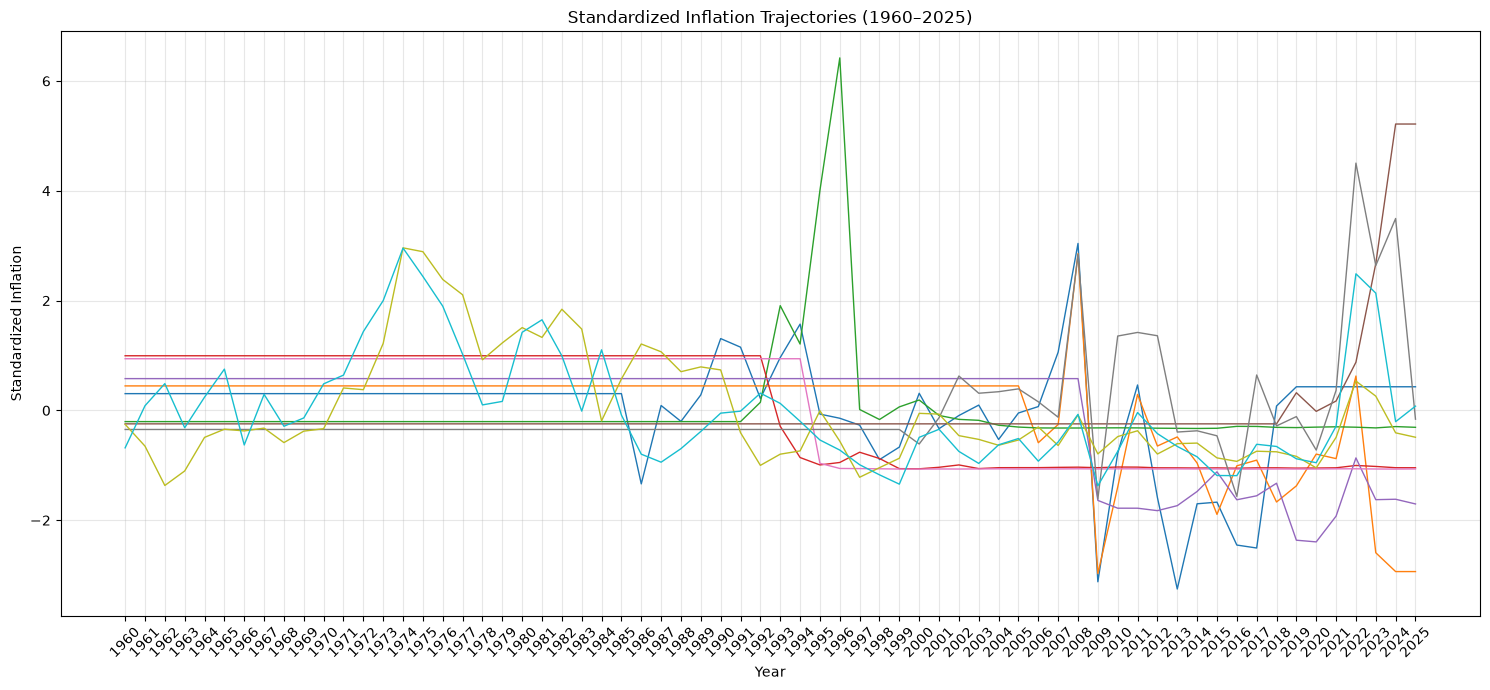

In [15]:
import matplotlib.pyplot as plt

plt.figure(figsize=(15, 7))

for i in range(min(10, X_scaled.shape[0])):
    plt.plot(
        CLUSTER_YEARS,
        X_scaled[i, :, 0],
        linewidth=1
    )

plt.title(
    "Standardized Inflation Trajectories (1960–2025)"
)

plt.xlabel("Year")
plt.ylabel("Standardized Inflation")

plt.xticks(rotation=45)
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [20]:
# Convert to:
# samples × time × features

X_scaled = scaled_values[:, :, np.newaxis]

print("Scaled time-series shape:", X_scaled.shape)

Scaled time-series shape: (193, 66, 1)


In [21]:
scaled_means = X_scaled[:, :, 0].mean(axis=1)
scaled_stds = X_scaled[:, :, 0].std(axis=1)

# Exclude only the constant trajectory when checking
# whether normal countries have mean ~0 and std ~1.
non_constant_mask = np.ones(
    len(scaled_stds),
    dtype=bool
)

for code in zero_variance_countries:
    non_constant_mask[
        cluster_data["Country Code"].to_numpy() == code
    ] = False

print(
    "Maximum absolute mean "
    "(non-constant countries):",
    np.max(
        np.abs(
            scaled_means[non_constant_mask]
        )
    )
)

print(
    "Minimum std "
    "(non-constant countries):",
    np.min(
        scaled_stds[non_constant_mask]
    )
)

print(
    "Maximum std "
    "(non-constant countries):",
    np.max(
        scaled_stds[non_constant_mask]
    )
)

# Tuvalu check
tuvalu_idx = np.where(
    cluster_data["Country Code"].to_numpy() == "TUV"
)[0][0]

print("\nTuvalu:")
print("Mean:", scaled_means[tuvalu_idx])
print("Std:", scaled_stds[tuvalu_idx])

Maximum absolute mean (non-constant countries): 9.689219124001365e-16
Minimum std (non-constant countries): 0.9999999999999994
Maximum std (non-constant countries): 1.0000000000000004

Tuvalu:
Mean: 0.0
Std: 0.0


In [22]:
from tslearn.clustering import TimeSeriesKMeans

print("Starting DTW Time-Series K-Means...")

test_model = TimeSeriesKMeans(
    n_clusters=3,
    metric="dtw",
    max_iter=30,
    max_iter_barycenter=20,
    n_init=1,
    random_state=42,
    n_jobs=-1,
    verbose=True
)

test_labels = test_model.fit_predict(X_scaled)

print("\nDTW clustering finished.")
print("Number of labels:", len(test_labels))
print(
    "Clusters found:",
    sorted(np.unique(test_labels))
)

Starting DTW Time-Series K-Means...


[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 12 concurrent workers.
[Parallel(n_jobs=-1)]: Done  26 tasks      | elapsed:   14.0s
[Parallel(n_jobs=-1)]: Done 193 out of 193 | elapsed:   14.0s finished
[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 12 concurrent workers.
[Parallel(n_jobs=-1)]: Done  26 tasks      | elapsed:    0.0s
[Parallel(n_jobs=-1)]: Done 176 tasks      | elapsed:    0.0s
[Parallel(n_jobs=-1)]: Done 426 tasks      | elapsed:    0.0s
[Parallel(n_jobs=-1)]: Done 579 out of 579 | elapsed:    0.0s finished
[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 12 concurrent workers.
[Parallel(n_jobs=-1)]: Done  26 tasks      | elapsed:    0.0s
[Parallel(n_jobs=-1)]: Done 176 tasks      | elapsed:    0.0s
[Parallel(n_jobs=-1)]: Done 426 tasks      | elapsed:    0.0s
[Parallel(n_jobs=-1)]: Done 579 out of 579 | elapsed:    0.1s finished
[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 12 concurrent workers.
[Parallel(n_jobs=-1)]: Do

31.538 --> 

[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 12 concurrent workers.
[Parallel(n_jobs=-1)]: Done  26 tasks      | elapsed:    0.0s
[Parallel(n_jobs=-1)]: Done 176 tasks      | elapsed:    0.0s
[Parallel(n_jobs=-1)]: Done 426 tasks      | elapsed:    0.0s
[Parallel(n_jobs=-1)]: Done 579 out of 579 | elapsed:    0.0s finished


17.042 --> 

...

[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 12 concurrent workers.
[Parallel(n_jobs=-1)]: Done  26 tasks      | elapsed:    0.0s
[Parallel(n_jobs=-1)]: Done 176 tasks      | elapsed:    0.0s
[Parallel(n_jobs=-1)]: Done 426 tasks      | elapsed:    0.0s
[Parallel(n_jobs=-1)]: Done 579 out of 579 | elapsed:    0.0s finished


16.567 --> 

[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 12 concurrent workers.
[Parallel(n_jobs=-1)]: Done  26 tasks      | elapsed:    0.0s
[Parallel(n_jobs=-1)]: Done 176 tasks      | elapsed:    0.0s
[Parallel(n_jobs=-1)]: Done 426 tasks      | elapsed:    0.0s
[Parallel(n_jobs=-1)]: Done 579 out of 579 | elapsed:    0.0s finished


16.567 --> 

DTW clustering finished.
Number of labels: 193
Clusters found: [np.int64(0), np.int64(1), np.int64(2)]


[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 12 concurrent workers.
[Parallel(n_jobs=-1)]: Done  26 tasks      | elapsed:    0.0s
[Parallel(n_jobs=-1)]: Done 176 tasks      | elapsed:    0.0s
[Parallel(n_jobs=-1)]: Done 426 tasks      | elapsed:    0.0s
[Parallel(n_jobs=-1)]: Done 579 out of 579 | elapsed:    0.0s finished


In [23]:
cluster_test_results = cluster_data[
    ["Country Name", "Country Code"]
].copy()

cluster_test_results["Cluster"] = test_labels

cluster_counts = (
    cluster_test_results["Cluster"]
    .value_counts()
    .sort_index()
)

print("Countries in each cluster:")
print(cluster_counts)

Countries in each cluster:
Cluster
0    58
1    71
2    64
Name: count, dtype: int64


In [24]:
for cluster_id in sorted(
    cluster_test_results["Cluster"].unique()
):

    print("\n" + "=" * 60)
    print(f"CLUSTER {cluster_id}")
    print("=" * 60)

    members = cluster_test_results[
        cluster_test_results["Cluster"] == cluster_id
    ]

    print(
        members["Country Name"]
        .to_string(index=False)
    )


CLUSTER 0
                         Aruba
                   Afghanistan
                       Albania
          United Arab Emirates
                       Armenia
                    Bangladesh
        Bosnia and Herzegovina
                       Belarus
                        Belize
             Brunei Darussalam
                        Bhutan
                      Botswana
                       Comoros
                    Cabo Verde
                Cayman Islands
                       Czechia
                      Djibouti
                       Estonia
                       Georgia
                        Guinea
                 Guinea-Bissau
                       Grenada
                        Guyana
          Hong Kong SAR, China
                    Kazakhstan
               Kyrgyz Republic
           St. Kitts and Nevis
                        Kuwait
                       Lao PDR
                       Liberia
                       Lesotho
                     Lithuan

In [25]:
india_result = cluster_test_results[
    cluster_test_results["Country Code"] == "IND"
]

if india_result.empty:
    print("India not found.")
else:
    india_cluster = int(
        india_result["Cluster"].iloc[0]
    )

    print(
        "India belongs to Cluster:",
        india_cluster
    )

India belongs to Cluster: 2


In [26]:
from tslearn.metrics import cdist_dtw

print("Calculating DTW distance matrix for evaluation...")

dtw_distance_matrix = cdist_dtw(
    X_scaled,
    n_jobs=-1,
    verbose=False
)

print("Done.")
print("DTW matrix shape:", dtw_distance_matrix.shape)

Calculating DTW distance matrix for evaluation...
Done.
DTW matrix shape: (193, 193)


In [27]:
from sklearn.metrics import silhouette_score
from tslearn.clustering import TimeSeriesKMeans

evaluation_results = []

for k in [2, 3, 4, 5, 6]:

    print(f"Evaluating K = {k}")

    model = TimeSeriesKMeans(
        n_clusters=k,
        metric="dtw",
        max_iter=50,
        max_iter_barycenter=20,
        n_init=2,
        random_state=42,
        n_jobs=-1,
        verbose=False
    )

    labels = model.fit_predict(X_scaled)

    silhouette = silhouette_score(
        dtw_distance_matrix,
        labels,
        metric="precomputed"
    )

    evaluation_results.append({
        "K": k,
        "DTW_Inertia": model.inertia_,
        "Silhouette_Score": silhouette
    })

evaluation_df = pd.DataFrame(evaluation_results)

display(evaluation_df)

Evaluating K = 2
Evaluating K = 3
Evaluating K = 4
Evaluating K = 5
Evaluating K = 6


,K,DTW_Inertia,Silhouette_Score
0,2,18.117312,0.296339
1,3,15.701529,0.214589
2,4,14.903750,0.169802
3,5,14.406904,0.144271
4,6,13.332064,0.142035


In [28]:
from tslearn.clustering import TimeSeriesKMeans
import numpy as np

FINAL_K = 2

final_model = TimeSeriesKMeans(
    n_clusters=FINAL_K,
    metric="dtw",
    max_iter=100,
    max_iter_barycenter=30,
    n_init=5,
    random_state=42,
    n_jobs=-1,
    verbose=False
)

final_labels = final_model.fit_predict(X_scaled)

print("Final DTW clustering completed.")
print("Final K:", FINAL_K)
print("Number of labels:", len(final_labels))
print("Clusters:", sorted(np.unique(final_labels)))

Final DTW clustering completed.
Final K: 2
Number of labels: 193
Clusters: [np.int64(0), np.int64(1)]


In [29]:
final_cluster_results = cluster_data[
    ["Country Name", "Country Code"]
].copy()

final_cluster_results["Cluster"] = final_labels

final_cluster_results = final_cluster_results.sort_values(
    ["Cluster", "Country Name"]
).reset_index(drop=True)

display(final_cluster_results.head(20))

,Country Name,Country Code,Cluster
0,Algeria,DZA,0
1,Angola,AGO,0
2,Antigua and Barbuda,ATG,0
3,Argentina,ARG,0
4,Australia,AUS,0
5,Austria,AUT,0
6,Azerbaijan,AZE,0
7,Bahrain,BHR,0
8,Barbados,BRB,0
9,Belgium,BEL,0


In [30]:
final_cluster_counts = (
    final_cluster_results["Cluster"]
    .value_counts()
    .sort_index()
)

print("Final cluster sizes:")
print(final_cluster_counts)

print("\nTotal countries:",
      final_cluster_counts.sum())

Final cluster sizes:
Cluster
0    123
1     70
Name: count, dtype: int64

Total countries: 193


In [31]:
india_final = final_cluster_results[
    final_cluster_results["Country Code"] == "IND"
]

print(india_final)

   Country Name Country Code  Cluster
49        India          IND        0


In [32]:
from sklearn.metrics import silhouette_score

final_silhouette = silhouette_score(
    dtw_distance_matrix,
    final_labels,
    metric="precomputed"
)

print(
    "Final DTW silhouette score:",
    round(final_silhouette, 6)
)

Final DTW silhouette score: 0.272094


In [33]:
india_final = final_cluster_results[
    final_cluster_results["Country Code"] == "IND"
]

print("India's final cluster:")
print(india_final)

India's final cluster:
   Country Name Country Code  Cluster
49        India          IND        0


In [34]:
for cluster_id in [0, 1]:
    members = final_cluster_results[
        final_cluster_results["Cluster"] == cluster_id
    ]

    print(f"\nCluster {cluster_id}: {len(members)} countries")
    print(members["Country Name"].to_list())


Cluster 0: 123 countries
['Algeria', 'Angola', 'Antigua and Barbuda', 'Argentina', 'Australia', 'Austria', 'Azerbaijan', 'Bahrain', 'Barbados', 'Belgium', 'Benin', 'Bolivia', 'Brazil', 'Bulgaria', 'Burkina Faso', 'Burundi', 'Cambodia', 'Cameroon', 'Canada', 'Central African Republic', 'Chile', 'Congo, Dem. Rep.', 'Congo, Rep.', 'Costa Rica', "Cote d'Ivoire", 'Croatia', 'Curacao', 'Cyprus', 'Denmark', 'Dominica', 'Dominican Republic', 'Ecuador', 'Egypt, Arab Rep.', 'El Salvador', 'Equatorial Guinea', 'Eswatini', 'Ethiopia', 'Fiji', 'Finland', 'Gabon', 'Gambia, The', 'Germany', 'Ghana', 'Greece', 'Guatemala', 'Haiti', 'Honduras', 'Hungary', 'Iceland', 'India', 'Indonesia', 'Iran, Islamic Rep.', 'Iraq', 'Ireland', 'Israel', 'Italy', 'Jamaica', 'Japan', 'Jordan', 'Kenya', 'Kiribati', 'Korea, Rep.', 'Kosovo', 'Lebanon', 'Luxembourg', 'Madagascar', 'Malawi', 'Malaysia', 'Mali', 'Malta', 'Mauritius', 'Mexico', 'Micronesia, Fed. Sts.', 'Montenegro', 'Morocco', 'Mozambique', 'Myanmar', 'Nether

In [37]:
# See the variables currently available in your notebook

%whos

Variable                       Type                Data/Info
------------------------------------------------------------
CLUSTER_YEARS                  list                n=66
END_YEAR                       int                 2025
FINAL_K                        int                 2
START_YEAR                     int                 1960
TimeSeriesKMeans               type                <class 'tslearn.clusterin<...>kmeans.TimeSeriesKMeans'>
TimeSeriesScalerMeanVariance   type                <class 'tslearn.preproces<...>eriesScalerMeanVariance'>
X                              ndarray             193x66x1: 12738 elems, type `float64`, 101904 bytes (99.515625 kb)
X_scaled                       ndarray             193x66x1: 12738 elems, type `float64`, 101904 bytes (99.515625 kb)
bad_mean                       ndarray             1: 1 elems, type `int64`, 8 bytes
bad_std                        ndarray             1: 1 elems, type `int64`, 8 bytes
cdist_dtw                      functi

In [38]:
print(final_cluster_results.head(10))
print("\nColumns:")
print(final_cluster_results.columns.tolist())

print("\nCluster counts:")
print(final_cluster_results.iloc[:, -1].value_counts())

          Country Name Country Code  Cluster
0              Algeria          DZA        0
1               Angola          AGO        0
2  Antigua and Barbuda          ATG        0
3            Argentina          ARG        0
4            Australia          AUS        0
5              Austria          AUT        0
6           Azerbaijan          AZE        0
7              Bahrain          BHR        0
8             Barbados          BRB        0
9              Belgium          BEL        0

Columns:
['Country Name', 'Country Code', 'Cluster']

Cluster counts:
Cluster
0    123
1     70
Name: count, dtype: int64


In [39]:
# ============================================
# STEP 1: Calculate average inflation
# pattern for each cluster
# ============================================

# Use the original inflation data
# and attach the final cluster labels

analysis_data = inflation_values.copy()

# Add country information
analysis_data.insert(0, "Country Name", final_cluster_results["Country Name"].values)
analysis_data.insert(1, "Country Code", final_cluster_results["Country Code"].values)

# Add final cluster
analysis_data["Cluster"] = final_cluster_results["Cluster"].values

# Calculate average inflation for each cluster by year
cluster_means = analysis_data.groupby("Cluster")[year_columns].mean()

print("Average inflation by cluster:")
print(cluster_means.round(2))

Average inflation by cluster:
          1960   1961   1962   1963   1964   1965    1966   1967   1968  \
Cluster                                                                   
0        92.08  92.06  92.97  93.59  93.35  94.49  101.44  92.45  93.14   
1        92.28  92.15  91.72  91.86  92.50  92.53   93.41  93.42  93.47   

          1969  ...   2016   2017  2018   2019   2020   2021   2022   2023  \
Cluster         ...                                                          
0        92.01  ...   3.38   4.11  3.57   3.51   3.94   6.14  11.51  10.14   
1        92.82  ...  13.77  10.72  9.77  12.89  17.98  15.51  16.54  15.76   

          2024   2025  
Cluster                
0         6.86   6.28  
1        14.57  12.44  

[2 rows x 66 columns]


In [40]:
# ============================================
# DATA VALIDATION
# Check what inflation_values actually contains
# ============================================

print("Shape:", inflation_values.shape)

print("\nFirst 10 rows:")
print(inflation_values.iloc[:10, :10])

print("\nStatistics:")
print(inflation_values.describe().round(2))

print("\nColumn names:")
print(inflation_values.columns.tolist())

Shape: (193, 66)

First 10 rows:
           1960         1961         1962         1963         1964  \
0      4.032258     4.032258     4.032258     4.032258     4.032258   
2     12.686269    12.686269    12.686269    12.686269    12.686269   
4     83.783784    83.783784    83.783784    83.783784    83.783784   
5    226.005421   226.005421   226.005421   226.005421   226.005421   
7     12.250420    12.250420    12.250420    12.250420    12.250420   
8     34.277224    34.277224    34.277224    34.277224    34.277224   
9   3373.759443  3373.759443  3373.759443  3373.759443  3373.759443   
10     1.121288     1.121288     1.121288     1.121288     1.121288   
11     3.728822     2.287580    -0.319489     0.641025     2.866227   
12     1.945749     3.542240     4.381799     2.708767     3.868564   

           1965         1966         1967         1968         1969  
0      4.032258     4.032258     4.032258     4.032258     4.032258  
2     12.686269    12.686269    12.686269    

In [41]:
# ============================================
# CHECK ORIGINAL DATA
# ============================================

print("WB shape:", wb.shape)

print("\nWB columns:")
print(wb.columns.tolist())

print("\nFirst 5 rows:")
print(wb.head())

WB shape: (240, 70)

WB columns:
['Country Name', 'Country Code', 'Indicator Name', 'Indicator Code', '1960', '1961', '1962', '1963', '1964', '1965', '1966', '1967', '1968', '1969', '1970', '1971', '1972', '1973', '1974', '1975', '1976', '1977', '1978', '1979', '1980', '1981', '1982', '1983', '1984', '1985', '1986', '1987', '1988', '1989', '1990', '1991', '1992', '1993', '1994', '1995', '1996', '1997', '1998', '1999', '2000', '2001', '2002', '2003', '2004', '2005', '2006', '2007', '2008', '2009', '2010', '2011', '2012', '2013', '2014', '2015', '2016', '2017', '2018', '2019', '2020', '2021', '2022', '2023', '2024', '2025']

First 5 rows:
                  Country Name Country Code  \
0                        Aruba          ABW   
1  Africa Eastern and Southern          AFE   
2                  Afghanistan          AFG   
3   Africa Western and Central          AFW   
4                       Angola          AGO   

                          Indicator Name  Indicator Code       1960  \
0

In [42]:
# ============================================
# CHECK PREPROCESSED INFLATION DATA
# ============================================

print("inflation_values shape:")
print(inflation_values.shape)

print("\nFirst 5 countries:")
print(inflation_values.iloc[:5, :10])

print("\nStatistics of inflation_values:")
print(inflation_values.describe().round(2))

print("\nOriginal WB statistics:")
print(wb[year_columns].describe().round(2))

inflation_values shape:
(193, 66)

First 5 countries:
         1960        1961        1962        1963        1964        1965  \
0    4.032258    4.032258    4.032258    4.032258    4.032258    4.032258   
2   12.686269   12.686269   12.686269   12.686269   12.686269   12.686269   
4   83.783784   83.783784   83.783784   83.783784   83.783784   83.783784   
5  226.005421  226.005421  226.005421  226.005421  226.005421  226.005421   
7   12.250420   12.250420   12.250420   12.250420   12.250420   12.250420   

         1966        1967        1968        1969  
0    4.032258    4.032258    4.032258    4.032258  
2   12.686269   12.686269   12.686269   12.686269  
4   83.783784   83.783784   83.783784   83.783784  
5  226.005421  226.005421  226.005421  226.005421  
7   12.250420   12.250420   12.250420   12.250420  

Statistics of inflation_values:
          1960     1961     1962     1963     1964     1965     1966     1967  \
count   193.00   193.00   193.00   193.00   193.00   193.

In [43]:
# ============================================
# COMPARE ORIGINAL vs PREPROCESSED VALUES
# ============================================

comparison = pd.DataFrame({
    "Country": wb["Country Name"].iloc[:193].values,
    "Original_1960": wb["1960"].iloc[:193].values,
    "Processed_1960": inflation_values["1960"].values
})

print(comparison.head(20).to_string(index=False))

                    Country  Original_1960  Processed_1960
                      Aruba       4.032258        4.032258
Africa Eastern and Southern      19.598394       12.686269
                Afghanistan      12.686269       83.783784
 Africa Western and Central       8.799211      226.005421
                     Angola      83.783784       12.250420
                    Albania     226.005421       34.277224
                 Arab World       8.266667     3373.759443
       United Arab Emirates      12.250420        1.121288
                  Argentina      34.277224        3.728822
                    Armenia    3373.759443        1.945749
        Antigua and Barbuda       1.121288      -10.630097
                  Australia       3.728822        4.436860
                    Austria       1.945749        0.299467
                 Azerbaijan     -10.630097        0.440599
                    Burundi       4.436860        7.788162
                    Belgium       0.299467        9.8746

In [44]:
# ============================================
# VERIFY THE 193 COUNTRIES USED IN CLUSTERING
# ============================================

print("Countries used for clustering:", len(final_cluster_results))
print("Inflation matrix countries:", inflation_values.shape[0])

print("\nFirst 10 clustered countries:")
print(final_cluster_results.head(10))

print("\nLast 10 clustered countries:")
print(final_cluster_results.tail(10))

Countries used for clustering: 193
Inflation matrix countries: 193

First 10 clustered countries:
          Country Name Country Code  Cluster
0              Algeria          DZA        0
1               Angola          AGO        0
2  Antigua and Barbuda          ATG        0
3            Argentina          ARG        0
4            Australia          AUS        0
5              Austria          AUT        0
6           Azerbaijan          AZE        0
7              Bahrain          BHR        0
8             Barbados          BRB        0
9              Belgium          BEL        0

Last 10 clustered countries:
             Country Name Country Code  Cluster
183           Timor-Leste          TLS        1
184                 Tonga          TON        1
185               Tunisia          TUN        1
186                Uganda          UGA        1
187               Ukraine          UKR        1
188  United Arab Emirates          ARE        1
189               Uruguay          URY   

Average Inflation by Cluster:


,1960,1961,1962,1963,1964,1965,1966,1967,1968,1969,...,2016,2017,2018,2019,2020,2021,2022,2023,2024,2025
Cluster,,,,,,,,,,,,,,,,,,,,,
0,92.08,92.06,92.97,93.59,93.35,94.49,101.44,92.45,93.14,92.01,...,3.38,4.11,3.57,3.51,3.94,6.14,11.51,10.14,6.86,6.28
1,92.28,92.15,91.72,91.86,92.50,92.53,93.41,93.42,93.47,92.82,...,13.77,10.72,9.77,12.89,17.98,15.51,16.54,15.76,14.57,12.44


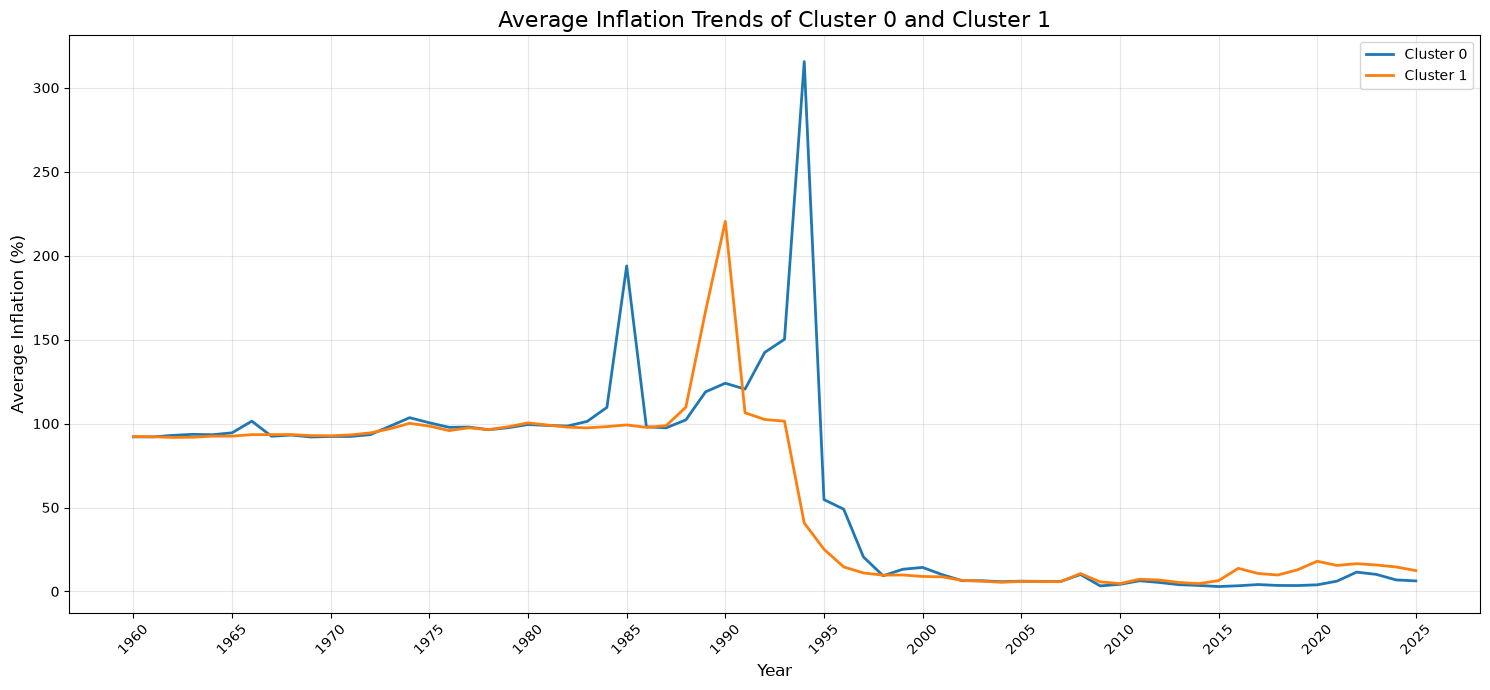

In [45]:
# ============================================
# FINAL CLUSTER ANALYSIS
# Cluster 0 vs Cluster 1
# ============================================

# Copy the inflation data
analysis_data = inflation_values.copy()

# Add country information from final clustering results
analysis_data.insert(
    0,
    "Country Name",
    final_cluster_results["Country Name"].values
)

analysis_data.insert(
    1,
    "Country Code",
    final_cluster_results["Country Code"].values
)

# Add final cluster labels
analysis_data["Cluster"] = final_cluster_results["Cluster"].values

# Calculate average inflation for each cluster
cluster_means = analysis_data.groupby("Cluster")[year_columns].mean()

# Display results
print("Average Inflation by Cluster:")
display(cluster_means.round(2))


# ============================================
# Plot cluster trends
# ============================================

plt.figure(figsize=(15, 7))

for cluster in cluster_means.index:
    plt.plot(
        year_columns,
        cluster_means.loc[cluster],
        linewidth=2,
        label=f"Cluster {cluster}"
    )

plt.title(
    "Average Inflation Trends of Cluster 0 and Cluster 1",
    fontsize=16
)

plt.xlabel("Year", fontsize=12)
plt.ylabel("Average Inflation (%)", fontsize=12)

plt.legend()
plt.grid(True, alpha=0.3)

plt.xticks(
    range(0, len(year_columns), 5),
    [year_columns[i] for i in range(0, len(year_columns), 5)],
    rotation=45
)

plt.tight_layout()
plt.show()

In [46]:
# ============================================
# COUNTRIES IN EACH CLUSTER
# ============================================

for cluster in sorted(final_cluster_results["Cluster"].unique()):

    members = final_cluster_results[
        final_cluster_results["Cluster"] == cluster
    ]

    print("\n" + "=" * 70)
    print(f"CLUSTER {cluster}")
    print("=" * 70)

    print(f"Number of countries: {len(members)}")

    display(
        members[
            ["Country Name", "Country Code", "Cluster"]
        ].reset_index(drop=True)
    )


CLUSTER 0
Number of countries: 123


,Country Name,Country Code,Cluster
0,Algeria,DZA,0
1,Angola,AGO,0
2,Antigua and Barbuda,ATG,0
3,Argentina,ARG,0
4,Australia,AUS,0
...,...,...,...
118,Vanuatu,VUT,0
119,"Venezuela, RB",VEN,0
120,Viet Nam,VNM,0
121,West Bank and Gaza,PSE,0



CLUSTER 1
Number of countries: 70


,Country Name,Country Code,Cluster
0,Afghanistan,AFG,1
1,Albania,ALB,1
2,Armenia,ARM,1
3,Aruba,ABW,1
4,"Bahamas, The",BHS,1
...,...,...,...
65,United Arab Emirates,ARE,1
66,Uruguay,URY,1
67,Uzbekistan,UZB,1
68,"Yemen, Rep.",YEM,1


In [47]:
# ============================================
# STATISTICAL SUMMARY OF EACH CLUSTER
# ============================================

cluster_summary = []

for cluster in sorted(analysis_data["Cluster"].unique()):

    cluster_data = analysis_data[
        analysis_data["Cluster"] == cluster
    ]

    values = cluster_data[year_columns].to_numpy().flatten()

    cluster_summary.append({
        "Cluster": cluster,
        "Countries": len(cluster_data),
        "Mean Inflation": values.mean(),
        "Median Inflation": np.median(values),
        "Minimum Inflation": values.min(),
        "Maximum Inflation": values.max(),
        "Std Deviation": values.std()
    })

cluster_summary = pd.DataFrame(cluster_summary)

print("Final Cluster Summary:")
display(cluster_summary.round(3))

Final Cluster Summary:


,Cluster,Countries,Mean Inflation,Median Inflation,Minimum Inflation,Maximum Inflation,Std Deviation
0,0,123,63.419,5.342,-17.640,23773.132,422.048
1,1,70,58.213,5.915,-13.057,7481.664,428.804


In [48]:
# ============================================
# INDIA'S FINAL CLUSTER
# ============================================

india_result = final_cluster_results[
    final_cluster_results["Country Code"] == "IND"
]

print("India's final clustering result:")
display(india_result)

India's final clustering result:


,Country Name,Country Code,Cluster
49,India,IND,0


In [49]:
# ============================================
# TOP COUNTRIES BY AVERAGE INFLATION
# ============================================

# Calculate average inflation for every country
country_average = analysis_data.copy()

country_average["Average Inflation"] = (
    country_average[year_columns].mean(axis=1)
)

# Sort from highest to lowest
top_inflation = country_average.sort_values(
    "Average Inflation",
    ascending=False
)

print("Top 20 countries by average inflation:")
display(
    top_inflation[
        ["Country Name", "Country Code", "Cluster", "Average Inflation"]
    ].head(20).round(2)
)

Top 20 countries by average inflation:


,Country Name,Country Code,Cluster,Average Inflation
224,St. Vincent and the Grenadines,VCT,1,2465.25
9,Azerbaijan,AZE,0,1793.82
107,Paraguay,PRY,0,1002.83
23,Chile,CHL,0,674.24
134,Suriname,SUR,0,550.62
39,Eswatini,SWZ,0,545.27
129,South Sudan,SSD,0,520.15
131,Sri Lanka,LKA,0,480.56
181,Grenada,GRD,1,464.55
25,"Congo, Rep.",COG,0,216.40


In [50]:
# ============================================
# LOWEST AVERAGE INFLATION
# ============================================

print("Bottom 20 countries by average inflation:")

display(
    top_inflation[
        ["Country Name", "Country Code", "Cluster", "Average Inflation"]
    ].tail(20).sort_values("Average Inflation").round(2)
)

Bottom 20 countries by average inflation:


,Country Name,Country Code,Cluster,Average Inflation
79,Malaysia,MYS,0,-4.69
235,United Arab Emirates,ARE,1,0.12
47,Ghana,GHA,0,0.17
161,Bhutan,BTN,1,0.21
164,Botswana,BWA,1,0.24
170,China,CHN,1,0.39
221,Slovak Republic,SVK,1,0.50
203,Mongolia,MNG,1,0.89
141,Trinidad and Tobago,TTO,0,1.48
110,Poland,POL,0,1.52


In [51]:
# ============================================
# INDIA'S INFLATION PROFILE
# ============================================

india_data = analysis_data[
    analysis_data["Country Code"] == "IND"
].copy()

india_data["Average Inflation"] = (
    india_data[year_columns].mean(axis=1)
)

print("India's inflation profile:")
display(
    india_data[
        ["Country Name", "Country Code", "Cluster", "Average Inflation"]
    ].round(2)
)

India's inflation profile:


,Country Name,Country Code,Cluster,Average Inflation
54,India,IND,0,10.07


In [52]:
# ============================================
# DIAGNOSTIC: ORIGINAL vs CLUSTERING DATA
# ============================================

# Match countries by Country Code, NOT by row number
original = wb[["Country Name", "Country Code"] + year_columns].copy()

processed = inflation_values.copy()

# Add country information from the final clustering order
processed.insert(
    0,
    "Country Name",
    final_cluster_results["Country Name"].values
)

processed.insert(
    1,
    "Country Code",
    final_cluster_results["Country Code"].values
)

# Compare selected years
comparison = original.merge(
    processed,
    on=["Country Name", "Country Code"],
    suffixes=("_Original", "_Processed")
)

check_years = ["1960", "1970", "1980", "1990", "2000", "2010", "2020", "2025"]

for year in check_years:
    comparison[f"{year}_Difference"] = (
        comparison[f"{year}_Processed"]
        - comparison[f"{year}_Original"]
    )

print("Comparison of original and processed inflation:")
display(
    comparison[
        ["Country Name", "Country Code"] +
        [
            item
            for year in check_years
            for item in [
                f"{year}_Original",
                f"{year}_Processed",
                f"{year}_Difference"
            ]
        ]
    ].head(20).round(3)
)

Comparison of original and processed inflation:


,Country Name,Country Code,1960_Original,1960_Processed,1960_Difference,1970_Original,1970_Processed,1970_Difference,1980_Original,1980_Processed,...,2000_Difference,2010_Original,2010_Processed,2010_Difference,2020_Original,2020_Processed,2020_Difference,2025_Original,2025_Processed,2025_Difference
0,Aruba,ABW,4.032,5.444,1.412,4.032,13.757,9.725,4.032,9.972,...,2.889,2.078,13.740,11.662,4.257,13.246,8.989,4.257,23.010,18.753
1,Afghanistan,AFG,12.686,7.136,-5.550,12.686,7.136,-5.550,12.686,7.136,...,-5.550,2.179,4.875,2.696,5.602,2.209,-3.393,-6.601,3.511,10.112
2,Angola,AGO,83.784,12.686,-71.098,83.784,12.686,-71.098,83.784,12.686,...,-312.311,14.470,2.179,-12.291,22.272,5.602,-16.670,20.162,-6.601,-26.763
3,Albania,ALB,226.005,2.429,-223.576,226.005,2.429,-223.576,226.005,2.429,...,2.379,3.627,2.429,-1.198,1.621,0.578,-1.043,2.146,0.578,-1.568
4,United Arab Emirates,ARE,12.250,-1.085,-13.335,12.250,-1.085,-13.335,12.250,-1.085,...,-13.335,0.878,3.481,2.603,-2.079,0.198,2.278,1.251,3.860,2.609
5,Argentina,ARG,34.277,226.005,191.728,34.277,226.005,191.728,34.277,226.005,...,-34.227,34.277,3.627,-30.650,42.015,1.621,-40.394,219.884,2.146,-217.738
6,Armenia,ARM,3373.759,1.004,-3372.755,3373.759,1.118,-3372.642,3373.759,10.305,...,3.691,8.176,0.804,-7.372,1.211,2.898,1.687,3.307,-4.455,-7.762
7,Antigua and Barbuda,ATG,1.121,83.784,82.662,1.121,83.784,82.662,1.121,83.784,...,324.225,3.370,14.470,11.100,0.626,22.272,21.646,1.369,20.162,18.793
8,Australia,AUS,3.729,12.250,8.522,3.439,12.250,8.811,10.136,12.250,...,7.793,2.918,0.878,-2.040,0.847,-2.079,-2.926,2.874,1.251,-1.623
9,Austria,AUT,1.946,34.277,32.331,4.373,34.277,29.904,6.328,34.277,...,31.932,1.814,34.277,32.464,1.382,42.015,40.633,3.527,219.884,216.357


In [53]:
# ============================================
# CHECK HOW MUCH THE DATA CHANGED
# ============================================

differences = []

for year in year_columns:

    diff = (
        comparison[f"{year}_Processed"]
        - comparison[f"{year}_Original"]
    )

    differences.append({
        "Year": year,
        "Mean Absolute Difference": diff.abs().mean(),
        "Maximum Absolute Difference": diff.abs().max()
    })

difference_summary = pd.DataFrame(differences)

display(difference_summary.round(3))

,Year,Mean Absolute Difference,Maximum Absolute Difference
0,1960,176.498,4732.259
1,1961,175.986,4732.259
2,1962,177.208,4732.259
3,1963,177.747,4734.225
4,1964,177.337,4729.606
...,...,...,...
61,2021,13.850,357.691
62,2022,15.015,245.423
63,2023,16.312,249.995
64,2024,14.420,252.457


In [54]:
# ============================================
# CHECK INDIA SPECIFICALLY
# ============================================

india_check = comparison[
    comparison["Country Code"] == "IND"
]

display(
    india_check[
        ["Country Name", "Country Code"] +
        [
            item
            for year in check_years
            for item in [
                f"{year}_Original",
                f"{year}_Processed"
            ]
        ]
    ].round(3)
)

,Country Name,Country Code,1960_Original,1960_Processed,1970_Original,1970_Processed,1980_Original,1980_Processed,1990_Original,1990_Processed,2000_Original,2000_Processed,2010_Original,2010_Processed,2020_Original,2020_Processed,2025_Original,2025_Processed
78,India,IND,1.78,-3.562,5.092,3.817,11.346,16.753,8.971,50.462,4.009,7.724,11.989,6.33,6.623,3.781,2.399,3.873


In [55]:
countries

,Country Name,Country Code,Indicator Name,Indicator Code,1960,1961,1962,1963,1964,1965,...,2017,2018,2019,2020,2021,2022,2023,2024,2025,Region
0,Aruba,ABW,"Inflation, consumer prices (annual %)",FP.CPI.TOTL.ZG,4.032258,4.032258,4.032258,4.032258,4.032258,4.032258,...,-1.028282,3.626041,4.257462,4.257462,4.257462,4.257462,4.257462,4.257462,4.257462,Latin America & Caribbean
2,Afghanistan,AFG,"Inflation, consumer prices (annual %)",FP.CPI.TOTL.ZG,12.686269,12.686269,12.686269,12.686269,12.686269,12.686269,...,4.975952,0.626149,2.302373,5.601888,5.133203,13.712102,-4.644709,-6.601186,-6.601186,Middle East & North Africa
4,Angola,AGO,"Inflation, consumer prices (annual %)",FP.CPI.TOTL.ZG,83.783784,83.783784,83.783784,83.783784,83.783784,83.783784,...,29.844480,19.628938,17.080954,22.271539,25.754295,21.355290,13.644102,28.240495,20.162020,Sub-Saharan Africa
5,Albania,ALB,"Inflation, consumer prices (annual %)",FP.CPI.TOTL.ZG,226.005421,226.005421,226.005421,226.005421,226.005421,226.005421,...,1.986661,2.028060,1.411091,1.620887,2.041472,6.725203,4.758346,2.215874,2.146186,Europe & Central Asia
7,United Arab Emirates,ARE,"Inflation, consumer prices (annual %)",FP.CPI.TOTL.ZG,12.250420,12.250420,12.250420,12.250420,12.250420,12.250420,...,1.966826,3.068634,-1.931081,-2.079403,0.179935,5.291226,1.626708,1.663365,1.250865,Middle East & North Africa
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
235,Kosovo,XKX,"Inflation, consumer prices (annual %)",FP.CPI.TOTL.ZG,-1.084813,-1.084813,-1.084813,-1.084813,-1.084813,-1.084813,...,1.488234,1.053798,2.675992,0.198228,3.353691,11.580510,4.944324,1.619450,3.859539,Europe & Central Asia
236,"Yemen, Rep.",YEM,"Inflation, consumer prices (annual %)",FP.CPI.TOTL.ZG,36.000000,36.000000,36.000000,36.000000,36.000000,36.000000,...,8.104726,8.104726,8.104726,8.104726,8.104726,8.104726,8.104726,8.104726,8.104726,Middle East & North Africa
237,South Africa,ZAF,"Inflation, consumer prices (annual %)",FP.CPI.TOTL.ZG,1.288877,2.102351,1.246275,1.337971,2.534989,4.069019,...,5.186187,4.509873,4.102851,3.232388,4.618745,7.039873,6.075244,4.361152,3.205505,Sub-Saharan Africa
238,Zambia,ZMB,"Inflation, consumer prices (annual %)",FP.CPI.TOTL.ZG,55.828221,55.828221,55.828221,55.828221,55.828221,55.828221,...,6.577312,7.494572,9.150316,15.733060,22.020768,10.993204,10.884532,14.985626,13.909910,Sub-Saharan Africa


In [56]:
# ============================================
# CHECK COUNTRY ORDER USED FOR CLUSTERING
# ============================================

print("First 20 countries in 'countries':")

display(
    countries[
        ["Country Name", "Country Code"]
    ].head(20)
)

print("\nFirst 20 countries in 'final_cluster_results':")

display(
    final_cluster_results[
        ["Country Name", "Country Code", "Cluster"]
    ].head(20)
)

First 20 countries in 'countries':


,Country Name,Country Code
0,Aruba,ABW
2,Afghanistan,AFG
4,Angola,AGO
5,Albania,ALB
7,United Arab Emirates,ARE
8,Argentina,ARG
9,Armenia,ARM
10,Antigua and Barbuda,ATG
11,Australia,AUS
12,Austria,AUT



First 20 countries in 'final_cluster_results':


,Country Name,Country Code,Cluster
0,Algeria,DZA,0
1,Angola,AGO,0
2,Antigua and Barbuda,ATG,0
3,Argentina,ARG,0
4,Australia,AUS,0
5,Austria,AUT,0
6,Azerbaijan,AZE,0
7,Bahrain,BHR,0
8,Barbados,BRB,0
9,Belgium,BEL,0


In [57]:
# ============================================
# CHECK WHETHER THE ORDERS ARE IDENTICAL
# ============================================

same_order = (
    countries["Country Code"].reset_index(drop=True)
    ==
    final_cluster_results["Country Code"].reset_index(drop=True)
)

print("Countries in same order:", same_order.all())
print("Number of matching positions:", same_order.sum())
print("Number of mismatched positions:", (~same_order).sum())

Countries in same order: False
Number of matching positions: 1
Number of mismatched positions: 192


In [58]:
# ============================================
# CHECK THE ACTUAL CLUSTERING COUNTRY ORDER
# ============================================

print("Countries DataFrame:")
display(
    countries[
        ["Country Name", "Country Code"]
    ].head(20)
)

print("\nLast 10 countries:")
display(
    countries[
        ["Country Name", "Country Code"]
    ].tail(10)
)

print("\nNumber of countries:", len(countries))

Countries DataFrame:


,Country Name,Country Code
0,Aruba,ABW
2,Afghanistan,AFG
4,Angola,AGO
5,Albania,ALB
7,United Arab Emirates,ARE
8,Argentina,ARG
9,Armenia,ARM
10,Antigua and Barbuda,ATG
11,Australia,AUS
12,Austria,AUT



Last 10 countries:


,Country Name,Country Code
229,St. Vincent and the Grenadines,VCT
230,"Venezuela, RB",VEN
231,Viet Nam,VNM
232,Vanuatu,VUT
234,Samoa,WSM
235,Kosovo,XKX
236,"Yemen, Rep.",YEM
237,South Africa,ZAF
238,Zambia,ZMB
239,Zimbabwe,ZWE



Number of countries: 193


In [59]:
# ============================================
# CHECK FINAL LABELS
# ============================================

print("Number of final labels:", len(final_labels))

print("\nFirst 20 final labels:")
print(final_labels[:20])

print("\nCluster counts:")
print(pd.Series(final_labels).value_counts().sort_index())

Number of final labels: 193

First 20 final labels:
[1 1 0 1 1 0 1 0 0 0 0 0 0 0 0 1 0 0 1 1]

Cluster counts:
0    123
1     70
Name: count, dtype: int64


In [60]:
# ============================================
# CHECK COUNTRY ORDER USED BY X / X_scaled
# ============================================

print("countries shape:", countries.shape)
print("X shape:", X.shape)
print("X_scaled shape:", X_scaled.shape)

print("\nFirst 20 countries used for X:")
display(
    countries[["Country Name", "Country Code"]].head(20)
)

print("\nFirst 20 final labels:")
print(final_labels[:20])

print("\nCountry count:", len(countries))
print("Label count:", len(final_labels))

countries shape: (193, 71)
X shape: (193, 66, 1)
X_scaled shape: (193, 66, 1)

First 20 countries used for X:


,Country Name,Country Code
0,Aruba,ABW
2,Afghanistan,AFG
4,Angola,AGO
5,Albania,ALB
7,United Arab Emirates,ARE
8,Argentina,ARG
9,Armenia,ARM
10,Antigua and Barbuda,ATG
11,Australia,AUS
12,Austria,AUT



First 20 final labels:
[1 1 0 1 1 0 1 0 0 0 0 0 0 0 0 1 0 0 1 1]

Country count: 193
Label count: 193


In [61]:
# ============================================
# CORRECT FINAL COUNTRY-CLUSTER MAPPING
# ============================================

correct_final_results = countries[
    ["Country Name", "Country Code"]
].copy()

correct_final_results["Cluster"] = final_labels

print("Corrected cluster results:")
display(correct_final_results.head(20))

print("\nCluster counts:")
print(correct_final_results["Cluster"].value_counts().sort_index())

Corrected cluster results:


,Country Name,Country Code,Cluster
0,Aruba,ABW,1
2,Afghanistan,AFG,1
4,Angola,AGO,0
5,Albania,ALB,1
7,United Arab Emirates,ARE,1
8,Argentina,ARG,0
9,Armenia,ARM,1
10,Antigua and Barbuda,ATG,0
11,Australia,AUS,0
12,Austria,AUT,0



Cluster counts:
Cluster
0    123
1     70
Name: count, dtype: int64


In [62]:
# ============================================
# INDIA'S CORRECT CLUSTER
# ============================================

india_cluster_result = correct_final_results[
    correct_final_results["Country Code"] == "IND"
]

print("India's correct cluster:")
display(india_cluster_result)

India's correct cluster:


,Country Name,Country Code,Cluster
97,India,IND,0


In [63]:
# ============================================
# COUNTRIES IN EACH CLUSTER
# ============================================

for cluster in sorted(correct_final_results["Cluster"].unique()):

    members = correct_final_results[
        correct_final_results["Cluster"] == cluster
    ]

    print("\n" + "=" * 70)
    print(f"CLUSTER {cluster}")
    print("=" * 70)
    print(f"Number of countries: {len(members)}")

    display(
        members[
            ["Country Name", "Country Code"]
        ].reset_index(drop=True)
    )


CLUSTER 0
Number of countries: 123


,Country Name,Country Code
0,Angola,AGO
1,Argentina,ARG
2,Antigua and Barbuda,ATG
3,Australia,AUS
4,Austria,AUT
...,...,...
118,Vanuatu,VUT
119,Samoa,WSM
120,Kosovo,XKX
121,South Africa,ZAF



CLUSTER 1
Number of countries: 70


,Country Name,Country Code
0,Aruba,ABW
1,Afghanistan,AFG
2,Albania,ALB
3,United Arab Emirates,ARE
4,Armenia,ARM
...,...,...
65,Uruguay,URY
66,Uzbekistan,UZB
67,St. Vincent and the Grenadines,VCT
68,"Yemen, Rep.",YEM


In [64]:
# ============================================
# SAVE FINAL RESULTS
# ============================================

final_cluster_results_corrected = correct_final_results.copy()

print("Final corrected clustering results ready.")

print("\nTotal countries:",
      len(final_cluster_results_corrected))

print("\nCluster sizes:")
print(
    final_cluster_results_corrected["Cluster"]
    .value_counts()
    .sort_index()
)

print("\nDTW Silhouette Score:",
      round(final_silhouette, 6))

Final corrected clustering results ready.

Total countries: 193

Cluster sizes:
Cluster
0    123
1     70
Name: count, dtype: int64

DTW Silhouette Score: 0.272094


In [65]:
# ============================================
# FINAL CLUSTER INFLATION PROFILES
# ============================================

# Create a DataFrame from the ORIGINAL inflation
# values in the same order as the clustering data

profile_data = countries[
    ["Country Name", "Country Code"]
].copy()

# Add the original inflation time series
for i, year in enumerate(year_columns):
    profile_data[year] = inflation_matrix[:, i]

# Add the correct cluster labels
profile_data["Cluster"] = final_labels

# --------------------------------------------
# Calculate average inflation for each cluster
# --------------------------------------------

cluster_profiles = (
    profile_data
    .groupby("Cluster")[year_columns]
    .mean()
)

print("Average inflation profile of each cluster:")
display(cluster_profiles.round(2))

Average inflation profile of each cluster:


,1960,1961,1962,1963,1964,1965,1966,1967,1968,1969,...,2016,2017,2018,2019,2020,2021,2022,2023,2024,2025
Cluster,,,,,,,,,,,,,,,,,,,,,
0,5.96,6.00,6.75,7.20,7.24,8.35,15.52,6.65,7.10,6.29,...,9.29,8.12,6.99,8.94,12.44,12.4,15.75,15.41,12.79,11.22
1,243.62,243.37,243.23,243.66,243.81,243.89,244.38,244.17,244.66,243.45,...,3.38,3.68,3.76,3.35,3.05,4.5,9.09,6.50,4.15,3.75


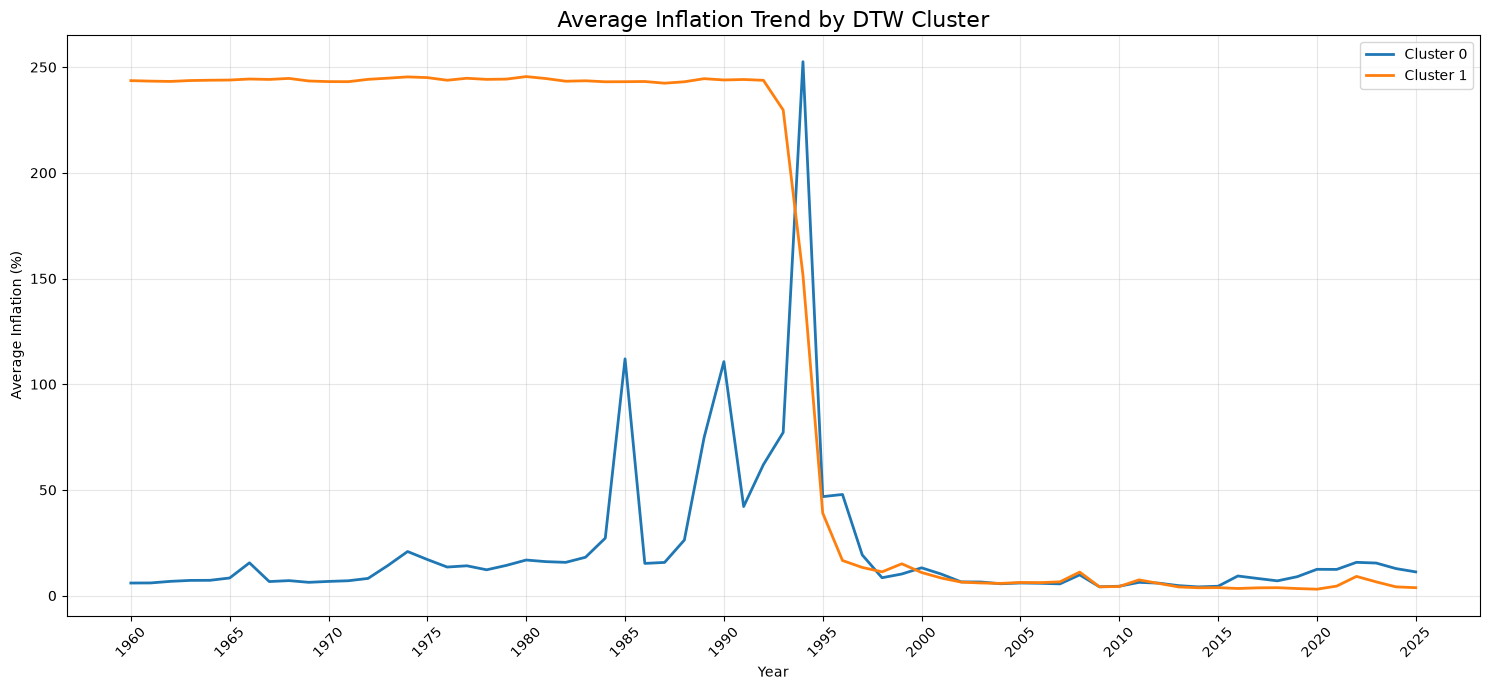

In [66]:
# ============================================
# CLUSTER INFLATION TREND
# ============================================

plt.figure(figsize=(15, 7))

for cluster in cluster_profiles.index:

    plt.plot(
        year_columns,
        cluster_profiles.loc[cluster],
        linewidth=2,
        label=f"Cluster {cluster}"
    )

plt.title(
    "Average Inflation Trend by DTW Cluster",
    fontsize=16
)

plt.xlabel("Year")
plt.ylabel("Average Inflation (%)")

plt.legend()
plt.grid(True, alpha=0.3)

# Show every 5th year
tick_positions = range(0, len(year_columns), 5)

plt.xticks(
    tick_positions,
    [year_columns[i] for i in tick_positions],
    rotation=45
)

plt.tight_layout()
plt.show()

In [67]:
# ============================================
# INDIA'S FINAL RESULT
# ============================================

india = profile_data[
    profile_data["Country Code"] == "IND"
]

print("India:")
display(
    india[
        ["Country Name", "Country Code", "Cluster"]
    ]
)

India:


,Country Name,Country Code,Cluster
97,India,IND,0


In [68]:
# ============================================
# CHECK inflation_matrix
# ============================================

print("inflation_matrix shape:", inflation_matrix.shape)

print("\nOverall statistics:")
print(pd.Series(inflation_matrix.flatten()).describe())

print("\nFirst 10 countries and their 1960 values:")
display(
    pd.DataFrame({
        "Country": countries["Country Name"].head(10).values,
        "Code": countries["Country Code"].head(10).values,
        "1960": inflation_matrix[:10, 0],
        "1961": inflation_matrix[:10, 1],
        "1962": inflation_matrix[:10, 2]
    })
)

inflation_matrix shape: (193, 66)

Overall statistics:
count    12738.000000
mean        61.531091
std        424.534631
min        -17.640424
25%          2.171989
50%          5.592381
75%         11.959090
max      23773.131774
dtype: float64

First 10 countries and their 1960 values:


,Country,Code,1960,1961,1962
0,Aruba,ABW,4.032258,4.032258,4.032258
1,Afghanistan,AFG,12.686269,12.686269,12.686269
2,Angola,AGO,83.783784,83.783784,83.783784
3,Albania,ALB,226.005421,226.005421,226.005421
4,United Arab Emirates,ARE,12.250420,12.250420,12.250420
5,Argentina,ARG,34.277224,34.277224,34.277224
6,Armenia,ARM,3373.759443,3373.759443,3373.759443
7,Antigua and Barbuda,ATG,1.121288,1.121288,1.121288
8,Australia,AUS,3.728822,2.287580,-0.319489
9,Austria,AUT,1.945749,3.542240,4.381799


In [69]:
# ============================================
# FIND EXTREME VALUES
# ============================================

extreme_threshold = 100

extreme_rows = []

for i in range(inflation_matrix.shape[0]):
    for j in range(inflation_matrix.shape[1]):
        
        value = inflation_matrix[i, j]
        
        if abs(value) > extreme_threshold:
            extreme_rows.append({
                "Country": countries.iloc[i]["Country Name"],
                "Code": countries.iloc[i]["Country Code"],
                "Year": year_columns[j],
                "Inflation": value
            })

extreme_df = pd.DataFrame(extreme_rows)

print("Number of values above ±100%:",
      len(extreme_df))

display(
    extreme_df.sort_values(
        "Inflation",
        ascending=False
    ).head(30)
)

Number of values above ±100%: 632


,Country,Code,Year,Inflation
176,"Congo, Dem. Rep.",COD,1994,23773.131774
130,Bolivia,BOL,1985,11749.639632
472,Peru,PER,1990,7481.663611
605,Ukraine,UKR,1993,4734.914347
601,Ukraine,UKR,1989,4734.914347
600,Ukraine,UKR,1988,4734.914347
599,Ukraine,UKR,1987,4734.914347
598,Ukraine,UKR,1986,4734.914347
597,Ukraine,UKR,1985,4734.914347
596,Ukraine,UKR,1984,4734.914347


In [70]:
# ============================================
# EXTREME VALUES BY CLUSTER
# ============================================

temp = pd.DataFrame(
    inflation_matrix,
    columns=year_columns
)

temp["Country"] = countries["Country Name"].values
temp["Code"] = countries["Country Code"].values
temp["Cluster"] = final_labels

cluster1 = temp[temp["Cluster"] == 1]

print("Cluster 1 size:", len(cluster1))

print("\nCluster 1 average:")
display(
    cluster1[year_columns].mean().round(2)
)

print("\nCluster 1 countries with very high values:")
display(
    cluster1[
        ["Country", "Code", "Cluster", "1960", "1970", "1980", "1990"]
    ].sort_values(
        "1960",
        ascending=False
    ).head(20)
)

Cluster 1 size: 70

Cluster 1 average:


1960    243.62
1961    243.37
1962    243.23
1963    243.66
1964    243.81
         ...  
2021      4.50
2022      9.09
2023      6.50
2024      4.15
2025      3.75
Length: 66, dtype: float64


Cluster 1 countries with very high values:


,Country,Code,Cluster,1960,1970,1980,1990
179,Ukraine,UKR,1,4734.914347,4734.914347,4734.914347,4734.914347
6,Armenia,ARM,1,3373.759443,3373.759443,3373.759443,3373.759443
88,Kazakhstan,KAZ,1,1877.372395,1877.372395,1877.372395,1877.372395
20,Belarus,BLR,1,1190.229233,1190.229233,1190.229233,1190.229233
108,Moldova,MDA,1,1026.826264,1026.826264,1026.826264,1026.826264
103,Lithuania,LTU,1,1020.620565,1020.620565,1020.620565,1020.620565
105,Latvia,LVA,1,951.696195,951.696195,951.696195,951.696195
146,Russian Federation,RUS,1,874.245720,874.245720,874.245720,874.245720
117,Mongolia,MNG,1,268.150489,268.150489,268.150489,268.150489
145,Romania,ROU,1,230.622495,230.622495,230.622495,230.622495


In [72]:
# ============================================
# REBUILD ORIGINAL INFLATION DATA + CHECK
# ============================================

# Create original inflation dataframe directly from wb
original_inflation = wb[
    ["Country Name", "Country Code"] + year_columns
].copy()

print("Original data shape:", original_inflation.shape)

# --------------------------------------------
# 1. Overall missing values
# --------------------------------------------

total_missing = original_inflation[year_columns].isna().sum().sum()

print("\nTotal missing inflation values:", total_missing)

# --------------------------------------------
# 2. Missing values by year
# --------------------------------------------

missing_by_year = (
    original_inflation[year_columns]
    .isna()
    .sum()
)

print("\nMissing values by year:")
display(missing_by_year.to_frame("Missing Values"))

# --------------------------------------------
# 3. Missing values by country
# --------------------------------------------

missing_by_country = (
    original_inflation
    .set_index(["Country Name", "Country Code"])[year_columns]
    .isna()
    .sum(axis=1)
    .sort_values(ascending=False)
)

print("\nTop 30 countries with missing values:")
display(missing_by_country.head(30))

print(
    "\nCountries with ZERO missing values:",
    (missing_by_country == 0).sum()
)

print(
    "Countries with at least one missing value:",
    (missing_by_country > 0).sum()
)

# --------------------------------------------
# 4. Check problematic countries
# --------------------------------------------

problem_codes = [
    "UKR", "ARM", "KAZ", "BLR", "MDA",
    "LTU", "LVA", "RUS", "MNG", "ROU"
]

problem_original = original_inflation[
    original_inflation["Country Code"].isin(problem_codes)
]

print("\nProblematic countries in ORIGINAL World Bank data:")

display(
    problem_original[
        ["Country Name", "Country Code"] +
        ["1960", "1970", "1980", "1990",
         "2000", "2010", "2020", "2025"]
    ].round(3)
)

Original data shape: (240, 68)

Total missing inflation values: 0

Missing values by year:


,Missing Values
1960,0
1961,0
1962,0
1963,0
1964,0
...,...
2021,0
2022,0
2023,0
2024,0



Top 30 countries with missing values:


Country Name                 Country Code
Aruba                        ABW             0
Africa Eastern and Southern  AFE             0
Afghanistan                  AFG             0
Africa Western and Central   AFW             0
Angola                       AGO             0
Albania                      ALB             0
Arab World                   ARB             0
United Arab Emirates         ARE             0
Argentina                    ARG             0
Armenia                      ARM             0
Antigua and Barbuda          ATG             0
Australia                    AUS             0
Austria                      AUT             0
Azerbaijan                   AZE             0
Burundi                      BDI             0
Belgium                      BEL             0
Benin                        BEN             0
Burkina Faso                 BFA             0
Bangladesh                   BGD             0
Bulgaria                     BGR             0
Bahrain           


Countries with ZERO missing values: 240
Countries with at least one missing value: 0

Problematic countries in ORIGINAL World Bank data:


,Country Name,Country Code,1960,1970,1980,1990,2000,2010,2020,2025
9,Armenia,ARM,3373.759,3373.759,3373.759,3373.759,-0.791,8.176,1.211,3.307
23,Belarus,BLR,1190.229,1190.229,1190.229,1190.229,168.620,7.736,5.548,6.599
107,Kazakhstan,KAZ,1877.372,1877.372,1877.372,1877.372,13.181,7.400,6.718,11.388
129,Lithuania,LTU,1020.621,1020.621,1020.621,1020.621,0.982,1.319,1.200,3.792
131,Latvia,LVA,951.696,951.696,951.696,951.696,2.654,-1.085,0.219,3.746
134,Moldova,MDA,1026.826,1026.826,1026.826,1026.826,31.299,7.484,3.766,7.759
146,Mongolia,MNG,268.150,268.150,268.150,268.150,11.596,10.046,3.724,8.605
180,Romania,ROU,230.622,230.622,230.622,230.622,45.667,6.091,2.631,7.189
181,Russian Federation,RUS,874.246,874.246,874.246,874.246,20.799,6.849,3.382,8.720
224,Ukraine,UKR,4734.914,4734.914,4734.914,4734.914,28.203,9.373,2.732,12.730


In [73]:
# ============================================
# CHECK ORIGINAL WORLD BANK DATA
# ============================================

original_inflation = wb[
    ["Country Name", "Country Code"] + year_columns
].copy()

print("Original data shape:")
print(original_inflation.shape)

print("\nMissing values:")
print(
    original_inflation[year_columns]
    .isna()
    .sum()
    .sum()
)

print("\nMissing values by year:")
display(
    original_inflation[year_columns]
    .isna()
    .sum()
)

Original data shape:
(240, 68)

Missing values:
0

Missing values by year:


1960    0
1961    0
1962    0
1963    0
1964    0
       ..
2021    0
2022    0
2023    0
2024    0
2025    0
Length: 66, dtype: int64

In [74]:
# ============================================
# CHECK EXTREME VALUES IN ORIGINAL WB DATA
# ============================================

problem_codes = [
    "UKR", "ARM", "KAZ", "BLR", "MDA",
    "LTU", "LVA", "RUS", "MNG", "ROU"
]

problem_original = original_inflation[
    original_inflation["Country Code"].isin(problem_codes)
]

print("Problematic countries in ORIGINAL WB data:")

display(
    problem_original[
        ["Country Name", "Country Code"] +
        ["1960", "1970", "1980", "1990",
         "2000", "2010", "2020", "2025"]
    ].round(3)
)

Problematic countries in ORIGINAL WB data:


,Country Name,Country Code,1960,1970,1980,1990,2000,2010,2020,2025
9,Armenia,ARM,3373.759,3373.759,3373.759,3373.759,-0.791,8.176,1.211,3.307
23,Belarus,BLR,1190.229,1190.229,1190.229,1190.229,168.620,7.736,5.548,6.599
107,Kazakhstan,KAZ,1877.372,1877.372,1877.372,1877.372,13.181,7.400,6.718,11.388
129,Lithuania,LTU,1020.621,1020.621,1020.621,1020.621,0.982,1.319,1.200,3.792
131,Latvia,LVA,951.696,951.696,951.696,951.696,2.654,-1.085,0.219,3.746
134,Moldova,MDA,1026.826,1026.826,1026.826,1026.826,31.299,7.484,3.766,7.759
146,Mongolia,MNG,268.150,268.150,268.150,268.150,11.596,10.046,3.724,8.605
180,Romania,ROU,230.622,230.622,230.622,230.622,45.667,6.091,2.631,7.189
181,Russian Federation,RUS,874.246,874.246,874.246,874.246,20.799,6.849,3.382,8.720
224,Ukraine,UKR,4734.914,4734.914,4734.914,4734.914,28.203,9.373,2.732,12.730


In [75]:
# ============================================
# FIND MAXIMUM VALUES IN ORIGINAL WB DATA
# ============================================

numeric_values = original_inflation[year_columns]

print("Maximum inflation value in original WB data:")
print(numeric_values.max().max())

print("\nCountry/year containing the maximum:")

max_value = numeric_values.max().max()

for country_idx in range(len(original_inflation)):
    for year in year_columns:
        if original_inflation.iloc[country_idx][year] == max_value:
            print(
                original_inflation.iloc[country_idx]["Country Name"],
                original_inflation.iloc[country_idx]["Country Code"],
                year,
                max_value
            )

Maximum inflation value in original WB data:
23773.1317741016

Country/year containing the maximum:
Congo, Dem. Rep. COD 1994 23773.1317741016


In [76]:
# ============================================
# COMPARE ORIGINAL WB VS INFLATION MATRIX
# FOR EXTREME COUNTRIES
# ============================================

problem_codes = [
    "UKR", "ARM", "KAZ", "BLR", "MDA",
    "LTU", "LVA", "RUS", "MNG", "ROU"
]

# Original data
problem_original = original_inflation[
    original_inflation["Country Code"].isin(problem_codes)
].copy()

print("ORIGINAL WORLD BANK VALUES")
print("=" * 80)

display(
    problem_original[
        ["Country Name", "Country Code"] +
        ["1960", "1970", "1980", "1990",
         "2000", "2010", "2020", "2025"]
    ].round(3)
)


# --------------------------------------------
# Find same countries in inflation_matrix
# --------------------------------------------

matrix_df = pd.DataFrame(
    inflation_matrix,
    columns=year_columns
)

matrix_df.insert(
    0,
    "Country Name",
    countries["Country Name"].values
)

matrix_df.insert(
    1,
    "Country Code",
    countries["Country Code"].values
)

problem_matrix = matrix_df[
    matrix_df["Country Code"].isin(problem_codes)
].copy()

print("\nINFLATION MATRIX VALUES")
print("=" * 80)

display(
    problem_matrix[
        ["Country Name", "Country Code"] +
        ["1960", "1970", "1980", "1990",
         "2000", "2010", "2020", "2025"]
    ].round(3)
)

ORIGINAL WORLD BANK VALUES


,Country Name,Country Code,1960,1970,1980,1990,2000,2010,2020,2025
9,Armenia,ARM,3373.759,3373.759,3373.759,3373.759,-0.791,8.176,1.211,3.307
23,Belarus,BLR,1190.229,1190.229,1190.229,1190.229,168.620,7.736,5.548,6.599
107,Kazakhstan,KAZ,1877.372,1877.372,1877.372,1877.372,13.181,7.400,6.718,11.388
129,Lithuania,LTU,1020.621,1020.621,1020.621,1020.621,0.982,1.319,1.200,3.792
131,Latvia,LVA,951.696,951.696,951.696,951.696,2.654,-1.085,0.219,3.746
134,Moldova,MDA,1026.826,1026.826,1026.826,1026.826,31.299,7.484,3.766,7.759
146,Mongolia,MNG,268.150,268.150,268.150,268.150,11.596,10.046,3.724,8.605
180,Romania,ROU,230.622,230.622,230.622,230.622,45.667,6.091,2.631,7.189
181,Russian Federation,RUS,874.246,874.246,874.246,874.246,20.799,6.849,3.382,8.720
224,Ukraine,UKR,4734.914,4734.914,4734.914,4734.914,28.203,9.373,2.732,12.730



INFLATION MATRIX VALUES


,Country Name,Country Code,1960,1970,1980,1990,2000,2010,2020,2025
6,Armenia,ARM,3373.759,3373.759,3373.759,3373.759,-0.791,8.176,1.211,3.307
20,Belarus,BLR,1190.229,1190.229,1190.229,1190.229,168.620,7.736,5.548,6.599
88,Kazakhstan,KAZ,1877.372,1877.372,1877.372,1877.372,13.181,7.400,6.718,11.388
103,Lithuania,LTU,1020.621,1020.621,1020.621,1020.621,0.982,1.319,1.200,3.792
105,Latvia,LVA,951.696,951.696,951.696,951.696,2.654,-1.085,0.219,3.746
108,Moldova,MDA,1026.826,1026.826,1026.826,1026.826,31.299,7.484,3.766,7.759
117,Mongolia,MNG,268.150,268.150,268.150,268.150,11.596,10.046,3.724,8.605
145,Romania,ROU,230.622,230.622,230.622,230.622,45.667,6.091,2.631,7.189
146,Russian Federation,RUS,874.246,874.246,874.246,874.246,20.799,6.849,3.382,8.720
179,Ukraine,UKR,4734.914,4734.914,4734.914,4734.914,28.203,9.373,2.732,12.730


In [77]:
# ============================================
# CHECK WHETHER EXTREME VALUES ARE REPEATED
# ============================================

print("Checking repeated values across years...")
print("=" * 80)

for code in problem_codes:

    row = matrix_df[
        matrix_df["Country Code"] == code
    ].iloc[0]

    values = row[year_columns].astype(float).values

    unique_values = np.unique(values)

    print(
        f"{code}: "
        f"{len(unique_values)} unique values "
        f"out of {len(year_columns)} years"
    )

Checking repeated values across years...
UKR: 33 unique values out of 66 years
ARM: 32 unique values out of 66 years
KAZ: 32 unique values out of 66 years
BLR: 33 unique values out of 66 years
MDA: 34 unique values out of 66 years
LTU: 34 unique values out of 66 years
LVA: 34 unique values out of 66 years
RUS: 33 unique values out of 66 years
MNG: 33 unique values out of 66 years
ROU: 35 unique values out of 66 years


In [78]:
# ============================================
# REBUILD CLUSTERING MATRIX DIRECTLY FROM WB
# ============================================

# Select the 193 countries used for clustering
# using the country codes already stored in `countries`

cluster_codes = countries["Country Code"].tolist()

# Get the corresponding rows directly from WB
wb_cluster = wb[
    wb["Country Code"].isin(cluster_codes)
].copy()

# IMPORTANT: restore EXACTLY the same order as `countries`
wb_cluster["order"] = wb_cluster["Country Code"].map(
    {code: i for i, code in enumerate(cluster_codes)}
)

wb_cluster = (
    wb_cluster
    .sort_values("order")
    .drop(columns="order")
    .reset_index(drop=True)
)

# Verify alignment
print("Countries:", len(countries))
print("WB cluster rows:", len(wb_cluster))

print(
    "Country order identical:",
    (
        countries["Country Code"].reset_index(drop=True)
        ==
        wb_cluster["Country Code"].reset_index(drop=True)
    ).all()
)

# Build fresh inflation matrix
X_original = wb_cluster[year_columns].to_numpy(dtype=float)

print("\nFresh matrix shape:", X_original.shape)

# Check for missing values
print(
    "Missing values:",
    np.isnan(X_original).sum()
)

# Check first few countries
display(
    wb_cluster[
        ["Country Name", "Country Code"]
    ].head(10)
)

Countries: 193
WB cluster rows: 193
Country order identical: True

Fresh matrix shape: (193, 66)
Missing values: 0


,Country Name,Country Code
0,Aruba,ABW
1,Afghanistan,AFG
2,Angola,AGO
3,Albania,ALB
4,United Arab Emirates,ARE
5,Argentina,ARG
6,Armenia,ARM
7,Antigua and Barbuda,ATG
8,Australia,AUS
9,Austria,AUT


In [79]:
# ============================================
# FRESH TIME-SERIES SCALING
# ============================================

X_fresh = X_original.reshape(
    X_original.shape[0],
    X_original.shape[1],
    1
)

scaler_fresh = TimeSeriesScalerMeanVariance()

X_fresh_scaled = scaler_fresh.fit_transform(X_fresh)

print("Fresh scaled matrix shape:",
      X_fresh_scaled.shape)

print(
    "Any NaN values:",
    np.isnan(X_fresh_scaled).sum()
)

Fresh scaled matrix shape: (193, 66, 1)
Any NaN values: 0


In [80]:
# ============================================
# FRESH DTW TIME-SERIES K-MEANS
# K = 2
# ============================================

fresh_model = TimeSeriesKMeans(
    n_clusters=2,
    metric="dtw",
    max_iter=50,
    random_state=42,
    verbose=True
)

fresh_labels = fresh_model.fit_predict(X_fresh_scaled)

print("\nFresh clustering completed.")

print("\nCluster sizes:")
print(
    pd.Series(fresh_labels)
    .value_counts()
    .sort_index()
)

39.103 --> 18.628 --> 18.570 --> 18.570 --> 

Fresh clustering completed.

Cluster sizes:
0     67
1    126
Name: count, dtype: int64


In [81]:
# ============================================
# FRESH DTW SILHOUETTE SCORE
# ============================================

fresh_dtw_distance_matrix = cdist_dtw(
    X_fresh_scaled
)

fresh_silhouette = silhouette_score(
    fresh_dtw_distance_matrix,
    fresh_labels,
    metric="precomputed"
)

print(
    "Fresh DTW silhouette score:",
    round(fresh_silhouette, 6)
)

Fresh DTW silhouette score: 0.275772


In [82]:
# ============================================
# NEW FINAL CLUSTER RESULTS
# ============================================

fresh_cluster_results = wb_cluster[
    ["Country Name", "Country Code"]
].copy()

fresh_cluster_results["Cluster"] = fresh_labels

print("First 10 countries:")
display(
    fresh_cluster_results.head(10)
)

print("\nCluster counts:")
print(
    fresh_cluster_results["Cluster"]
    .value_counts()
    .sort_index()
)

print("\nIndia:")
display(
    fresh_cluster_results[
        fresh_cluster_results["Country Code"] == "IND"
    ]
)

First 10 countries:


,Country Name,Country Code,Cluster
0,Aruba,ABW,0
1,Afghanistan,AFG,0
2,Angola,AGO,1
3,Albania,ALB,0
4,United Arab Emirates,ARE,0
5,Argentina,ARG,1
6,Armenia,ARM,0
7,Antigua and Barbuda,ATG,1
8,Australia,AUS,1
9,Austria,AUT,1



Cluster counts:
Cluster
0     67
1    126
Name: count, dtype: int64

India:


,Country Name,Country Code,Cluster
78,India,IND,1


In [83]:
print("Fresh DTW silhouette score:",
      round(fresh_silhouette, 6))

Fresh DTW silhouette score: 0.275772


In [84]:
# ============================================
# FINAL CLUSTER INFLATION PROFILES
# ============================================

# Create final analysis dataframe
final_analysis = wb_cluster[
    ["Country Name", "Country Code"] + year_columns
].copy()

# Add final DTW cluster
final_analysis["Cluster"] = fresh_labels

# Calculate average inflation for each cluster
final_cluster_profiles = (
    final_analysis
    .groupby("Cluster")[year_columns]
    .mean()
)

print("FINAL AVERAGE INFLATION BY CLUSTER:")
display(final_cluster_profiles.round(2))

FINAL AVERAGE INFLATION BY CLUSTER:


,1960,1961,1962,1963,1964,1965,1966,1967,1968,1969,...,2016,2017,2018,2019,2020,2021,2022,2023,2024,2025
Cluster,,,,,,,,,,,,,,,,,,,,,
0,253.96,253.70,253.67,253.78,254.02,254.30,254.57,254.75,255.26,253.80,...,2.78,3.17,3.52,3.34,2.99,4.41,9.02,6.41,4.10,3.69
1,6.11,6.16,6.83,7.45,7.44,8.42,15.55,6.69,7.12,6.43,...,9.47,8.28,7.04,8.82,12.25,12.26,15.63,15.25,12.61,11.08


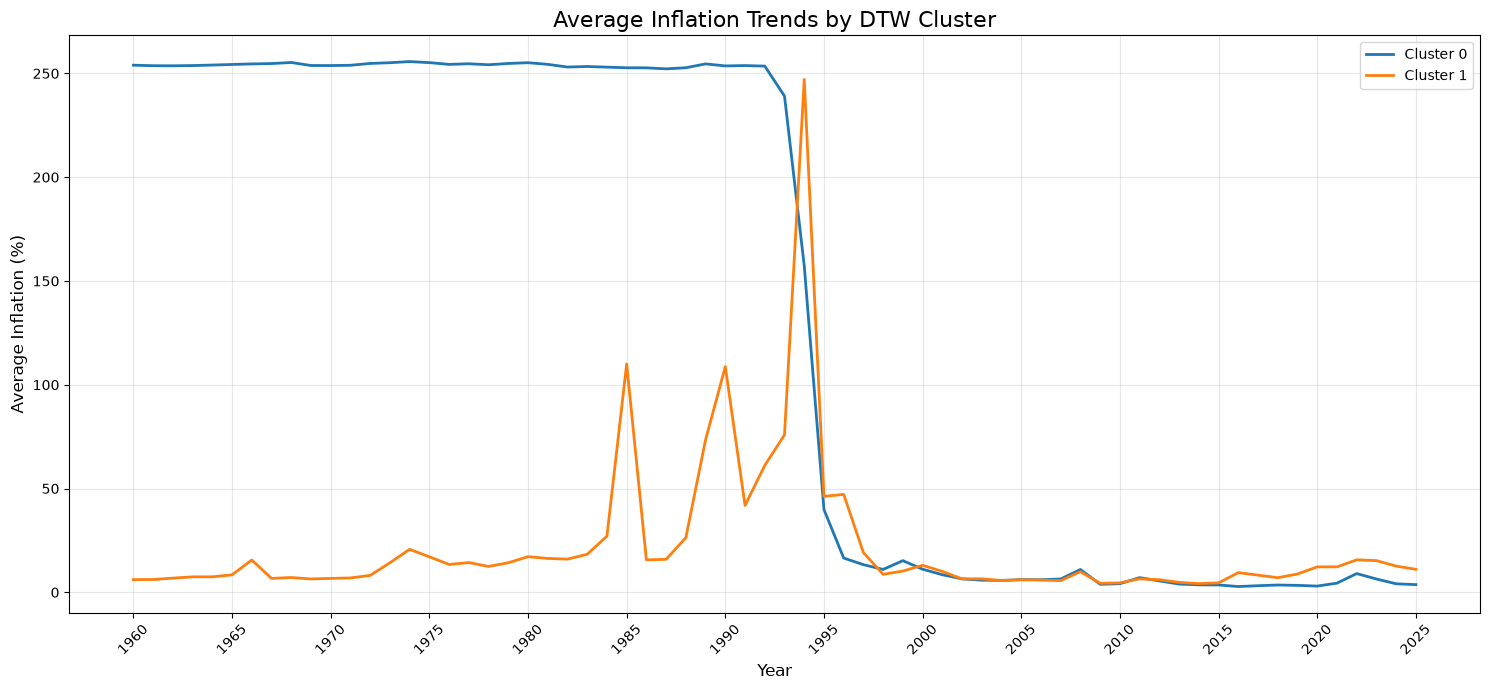

In [85]:
# ============================================
# FINAL CLUSTER TREND GRAPH
# ============================================

plt.figure(figsize=(15, 7))

for cluster in final_cluster_profiles.index:

    plt.plot(
        year_columns,
        final_cluster_profiles.loc[cluster],
        linewidth=2,
        label=f"Cluster {cluster}"
    )

plt.title(
    "Average Inflation Trends by DTW Cluster",
    fontsize=16
)

plt.xlabel("Year", fontsize=12)
plt.ylabel("Average Inflation (%)", fontsize=12)

plt.legend()
plt.grid(True, alpha=0.3)

tick_positions = range(0, len(year_columns), 5)

plt.xticks(
    tick_positions,
    [year_columns[i] for i in tick_positions],
    rotation=45
)

plt.tight_layout()
plt.show()

In [86]:
# ============================================
# FINAL CLUSTER SUMMARY
# ============================================

summary_rows = []

for cluster in sorted(final_analysis["Cluster"].unique()):

    cluster_data = final_analysis[
        final_analysis["Cluster"] == cluster
    ]

    all_values = cluster_data[
        year_columns
    ].to_numpy().flatten()

    summary_rows.append({
        "Cluster": cluster,
        "Countries": len(cluster_data),
        "Overall Mean Inflation": np.mean(all_values),
        "Median Inflation": np.median(all_values),
        "Minimum": np.min(all_values),
        "Maximum": np.max(all_values),
        "Std Dev": np.std(all_values)
    })

final_summary = pd.DataFrame(summary_rows)

display(final_summary.round(2))

,Cluster,Countries,Overall Mean Inflation,Median Inflation,Minimum,Maximum,Std Dev
0,0,67,136.63,7.81,-16.86,4734.91,561.39
1,1,126,21.60,4.41,-17.64,23773.13,322.29


In [87]:
# ============================================
# INDIA VS ITS CLUSTER
# ============================================

india = final_analysis[
    final_analysis["Country Code"] == "IND"
].iloc[0]

india_cluster = india["Cluster"]

print("India's cluster:", int(india_cluster))

india_values = india[year_columns].astype(float)

cluster_values = final_cluster_profiles.loc[
    india_cluster
]

comparison = pd.DataFrame({
    "Year": year_columns,
    "India": india_values.values,
    f"Cluster {int(india_cluster)} Average": cluster_values.values
})

display(comparison.round(2))

India's cluster: 1


,Year,India,Cluster 1 Average
0,1960,1.78,6.11
1,1961,1.70,6.16
2,1962,3.63,6.83
3,1963,2.95,7.45
4,1964,13.36,7.44
...,...,...,...
61,2021,5.13,12.26
62,2022,6.70,15.63
63,2023,5.65,15.25
64,2024,4.95,12.61


In [88]:
# ============================================
# FINAL CLUSTER COMPARISON
# ============================================

# Calculate overall average inflation for every country
country_stats = final_analysis[
    ["Country Name", "Country Code", "Cluster"] + year_columns
].copy()

country_stats["Mean Inflation"] = (
    country_stats[year_columns].mean(axis=1)
)

country_stats["Median Inflation"] = (
    country_stats[year_columns].median(axis=1)
)

# Cluster-level statistics
cluster_comparison = (
    country_stats
    .groupby("Cluster")
    [["Mean Inflation", "Median Inflation"]]
    .mean()
)

print("Cluster comparison:")
display(cluster_comparison.round(2))

Cluster comparison:


,Mean Inflation,Median Inflation
Cluster,,
0,136.63,239.44
1,21.60,7.63


In [89]:
# ============================================
# RECENT INFLATION COMPARISON
# ============================================

recent_years = [
    "2015", "2016", "2017", "2018",
    "2019", "2020", "2021", "2022",
    "2023", "2024", "2025"
]

recent_cluster_comparison = (
    final_analysis
    .groupby("Cluster")[recent_years]
    .mean()
)

print("Average inflation during 2015–2025:")
display(
    recent_cluster_comparison.round(2)
)

Average inflation during 2015–2025:


,2015,2016,2017,2018,2019,2020,2021,2022,2023,2024,2025
Cluster,,,,,,,,,,,
0,3.53,2.78,3.17,3.52,3.34,2.99,4.41,9.02,6.41,4.10,3.69
1,4.56,9.47,8.28,7.04,8.82,12.25,12.26,15.63,15.25,12.61,11.08


In [90]:
# ============================================
# COUNTRIES IN EACH CLUSTER
# ============================================

for cluster in sorted(fresh_cluster_results["Cluster"].unique()):

    members = fresh_cluster_results[
        fresh_cluster_results["Cluster"] == cluster
    ]

    print("\n" + "=" * 60)
    print(f"CLUSTER {cluster}")
    print("=" * 60)
    print(f"Countries: {len(members)}")

    display(members.reset_index(drop=True))


CLUSTER 0
Countries: 67


,Country Name,Country Code,Cluster
0,Aruba,ABW,0
1,Afghanistan,AFG,0
2,Albania,ALB,0
3,United Arab Emirates,ARE,0
4,Armenia,ARM,0
...,...,...,...
62,Uruguay,URY,0
63,Uzbekistan,UZB,0
64,St. Vincent and the Grenadines,VCT,0
65,"Yemen, Rep.",YEM,0



CLUSTER 1
Countries: 126


,Country Name,Country Code,Cluster
0,Angola,AGO,1
1,Argentina,ARG,1
2,Antigua and Barbuda,ATG,1
3,Australia,AUS,1
4,Austria,AUT,1
...,...,...,...
121,Vanuatu,VUT,1
122,Samoa,WSM,1
123,Kosovo,XKX,1
124,South Africa,ZAF,1


In [91]:
# ============================================
# 1. FINAL CLUSTER SUMMARY
# ============================================

final_analysis = wb_cluster[
    ["Country Name", "Country Code"] + year_columns
].copy()

final_analysis["Cluster"] = fresh_labels

cluster_summary = []

for cluster in sorted(final_analysis["Cluster"].unique()):

    data_cluster = final_analysis[
        final_analysis["Cluster"] == cluster
    ]

    values = data_cluster[year_columns].to_numpy().flatten()

    cluster_summary.append({
        "Cluster": cluster,
        "Number of Countries": len(data_cluster),
        "Percentage of Countries":
            len(data_cluster) / len(final_analysis) * 100,
        "Mean Inflation":
            np.mean(values),
        "Median Inflation":
            np.median(values),
        "Minimum Inflation":
            np.min(values),
        "Maximum Inflation":
            np.max(values),
        "Std Dev":
            np.std(values)
    })

cluster_summary_df = pd.DataFrame(cluster_summary)

print("FINAL CLUSTER SUMMARY")
display(cluster_summary_df.round(2))

FINAL CLUSTER SUMMARY


,Cluster,Number of Countries,Percentage of Countries,Mean Inflation,Median Inflation,Minimum Inflation,Maximum Inflation,Std Dev
0,0,67,34.72,136.63,7.81,-16.86,4734.91,561.39
1,1,126,65.28,21.60,4.41,-17.64,23773.13,322.29


In [92]:
# ============================================
# 2. AVERAGE INFLATION PROFILE
# ============================================

final_cluster_profiles = (
    final_analysis
    .groupby("Cluster")[year_columns]
    .mean()
)

print("AVERAGE INFLATION PROFILE OF EACH CLUSTER")
display(final_cluster_profiles.round(2))

AVERAGE INFLATION PROFILE OF EACH CLUSTER


,1960,1961,1962,1963,1964,1965,1966,1967,1968,1969,...,2016,2017,2018,2019,2020,2021,2022,2023,2024,2025
Cluster,,,,,,,,,,,,,,,,,,,,,
0,253.96,253.70,253.67,253.78,254.02,254.30,254.57,254.75,255.26,253.80,...,2.78,3.17,3.52,3.34,2.99,4.41,9.02,6.41,4.10,3.69
1,6.11,6.16,6.83,7.45,7.44,8.42,15.55,6.69,7.12,6.43,...,9.47,8.28,7.04,8.82,12.25,12.26,15.63,15.25,12.61,11.08


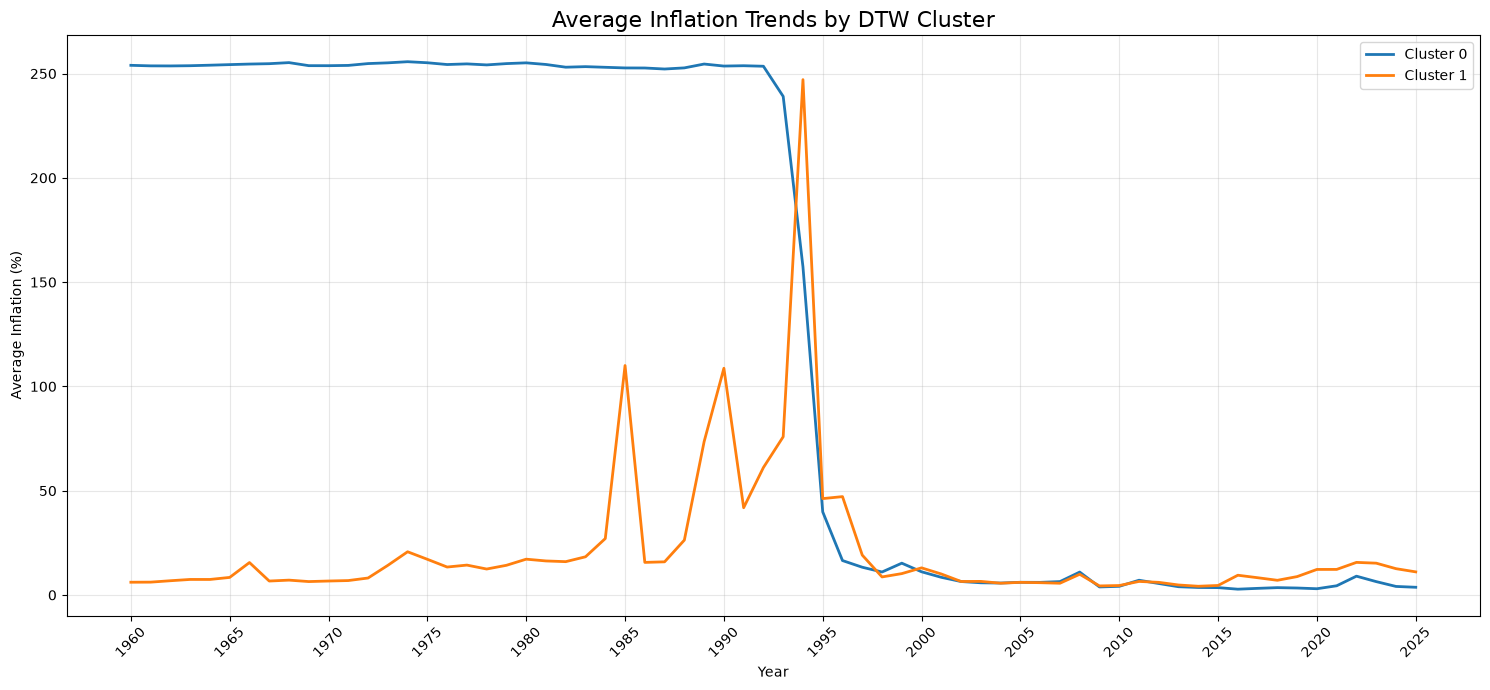

In [93]:
# ============================================
# 3. CLUSTER INFLATION TREND
# ============================================

plt.figure(figsize=(15, 7))

for cluster in final_cluster_profiles.index:

    plt.plot(
        year_columns,
        final_cluster_profiles.loc[cluster],
        linewidth=2,
        label=f"Cluster {cluster}"
    )

plt.title(
    "Average Inflation Trends by DTW Cluster",
    fontsize=16
)

plt.xlabel("Year")
plt.ylabel("Average Inflation (%)")

plt.legend()
plt.grid(True, alpha=0.3)

plt.xticks(
    range(0, len(year_columns), 5),
    [year_columns[i] for i in range(0, len(year_columns), 5)],
    rotation=45
)

plt.tight_layout()
plt.show()

In [94]:
# ============================================
# 4. INDIA VS CLUSTER 1
# ============================================

india = final_analysis[
    final_analysis["Country Code"] == "IND"
].iloc[0]

india_cluster = int(india["Cluster"])

india_comparison = pd.DataFrame({
    "Year": year_columns,
    "India": india[year_columns].astype(float).values,
    f"Cluster {india_cluster} Average":
        final_cluster_profiles.loc[india_cluster].values
})

print(f"India belongs to Cluster {india_cluster}")

display(india_comparison.round(2))

India belongs to Cluster 1


,Year,India,Cluster 1 Average
0,1960,1.78,6.11
1,1961,1.70,6.16
2,1962,3.63,6.83
3,1963,2.95,7.45
4,1964,13.36,7.44
...,...,...,...
61,2021,5.13,12.26
62,2022,6.70,15.63
63,2023,5.65,15.25
64,2024,4.95,12.61


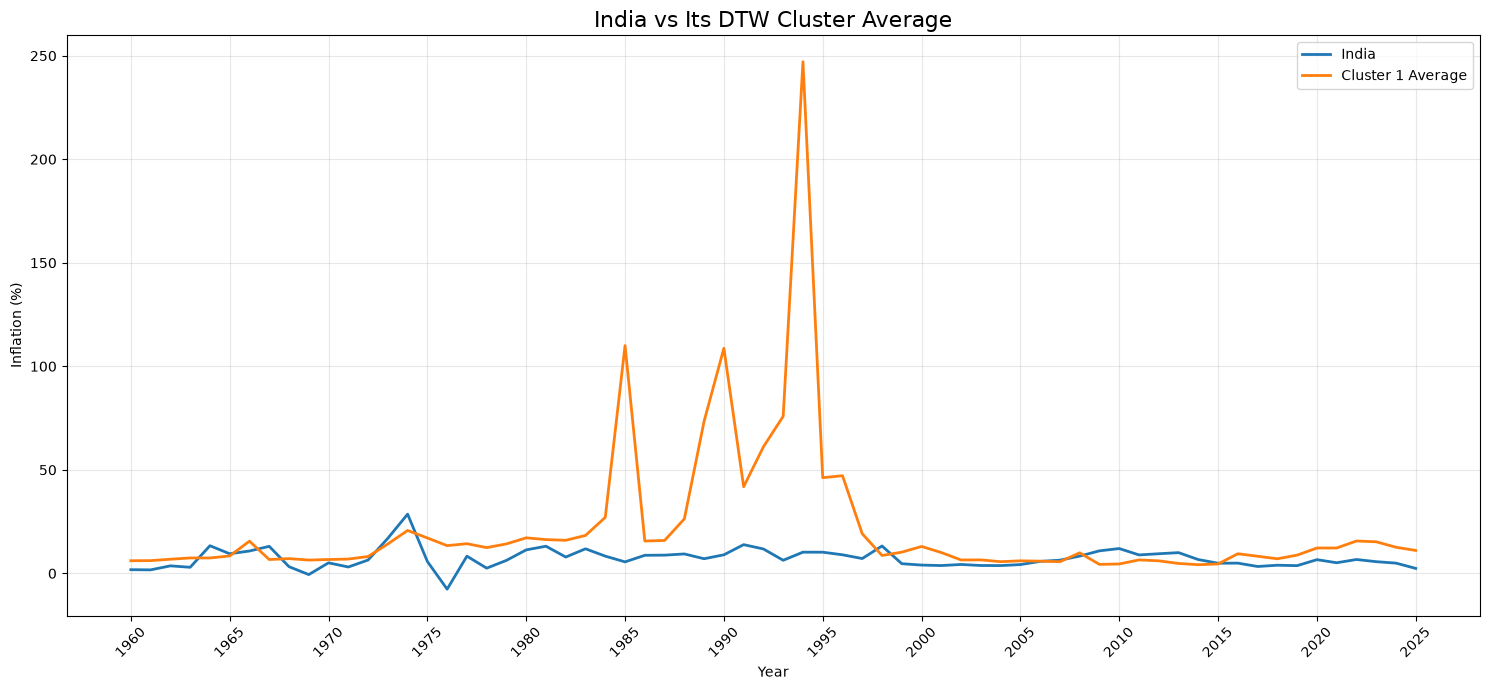

In [95]:
# ============================================
# 5. INDIA VS CLUSTER GRAPH
# ============================================

plt.figure(figsize=(15, 7))

plt.plot(
    year_columns,
    india_comparison["India"],
    linewidth=2,
    label="India"
)

plt.plot(
    year_columns,
    india_comparison[
        f"Cluster {india_cluster} Average"
    ],
    linewidth=2,
    label=f"Cluster {india_cluster} Average"
)

plt.title(
    "India vs Its DTW Cluster Average",
    fontsize=16
)

plt.xlabel("Year")
plt.ylabel("Inflation (%)")

plt.legend()
plt.grid(True, alpha=0.3)

plt.xticks(
    range(0, len(year_columns), 5),
    [year_columns[i] for i in range(0, len(year_columns), 5)],
    rotation=45
)

plt.tight_layout()
plt.show()

In [96]:
# ============================================
# 6. RECENT INFLATION COMPARISON
# ============================================

recent_years = [
    "2015", "2016", "2017", "2018",
    "2019", "2020", "2021", "2022",
    "2023", "2024", "2025"
]

recent_comparison = (
    final_analysis
    .groupby("Cluster")[recent_years]
    .mean()
)

print("AVERAGE INFLATION: 2015–2025")
display(recent_comparison.round(2))

AVERAGE INFLATION: 2015–2025


,2015,2016,2017,2018,2019,2020,2021,2022,2023,2024,2025
Cluster,,,,,,,,,,,
0,3.53,2.78,3.17,3.52,3.34,2.99,4.41,9.02,6.41,4.10,3.69
1,4.56,9.47,8.28,7.04,8.82,12.25,12.26,15.63,15.25,12.61,11.08


In [97]:
# ============================================
# 7. COUNTRY-LEVEL AVERAGE INFLATION
# ============================================

country_average = final_analysis[
    ["Country Name", "Country Code", "Cluster"]
].copy()

country_average["Average Inflation"] = (
    final_analysis[year_columns].mean(axis=1)
)

country_average = country_average.sort_values(
    "Average Inflation",
    ascending=False
)

print("TOP 20 COUNTRIES BY AVERAGE INFLATION")
display(
    country_average.head(20).reset_index(drop=True).round(2)
)

print("\nBOTTOM 20 COUNTRIES BY AVERAGE INFLATION")
display(
    country_average.tail(20)
    .sort_values("Average Inflation")
    .reset_index(drop=True)
    .round(2)
)

TOP 20 COUNTRIES BY AVERAGE INFLATION


,Country Name,Country Code,Cluster,Average Inflation
0,Ukraine,UKR,0,2465.25
1,Armenia,ARM,0,1793.82
2,Kazakhstan,KAZ,0,1002.83
3,Belarus,BLR,0,674.24
4,Moldova,MDA,0,550.62
5,"Congo, Dem. Rep.",COD,1,545.27
6,Lithuania,LTU,0,520.15
7,Latvia,LVA,0,480.56
8,Russian Federation,RUS,0,464.55
9,Bolivia,BOL,1,216.40



BOTTOM 20 COUNTRIES BY AVERAGE INFLATION


,Country Name,Country Code,Cluster,Average Inflation
0,Equatorial Guinea,GNQ,1,-4.69
1,Kosovo,XKX,1,0.12
2,Cayman Islands,CYM,0,0.17
3,Nauru,NRU,0,0.21
4,Oman,OMN,1,0.24
5,Palau,PLW,1,0.39
6,Tuvalu,TUV,1,0.50
7,Sint Maarten (Dutch part),SXM,1,0.89
8,Mali,MLI,1,1.48
9,Cambodia,KHM,1,1.52


In [98]:
# ============================================
# 8. INDIA STATISTICS
# ============================================

india_values = india[year_columns].astype(float)

india_stats = pd.DataFrame({
    "Metric": [
        "Cluster",
        "Average Inflation",
        "Median Inflation",
        "Minimum Inflation",
        "Maximum Inflation",
        "Standard Deviation"
    ],
    "Value": [
        india_cluster,
        india_values.mean(),
        india_values.median(),
        india_values.min(),
        india_values.max(),
        india_values.std()
    ]
})

print("INDIA INFLATION PROFILE")
display(india_stats.round(2))

INDIA INFLATION PROFILE


,Metric,Value
0,Cluster,1.00
1,Average Inflation,7.23
2,Median Inflation,6.53
3,Minimum Inflation,-7.63
4,Maximum Inflation,28.60
5,Standard Deviation,4.81


In [99]:
# ============================================
# 9. COUNTRIES MOST SIMILAR TO INDIA USING DTW
# ============================================

india_index = final_analysis.index[
    final_analysis["Country Code"] == "IND"
][0]

india_position = list(final_analysis.index).index(
    india_index
)

india_distances = fresh_dtw_distance_matrix[
    india_position
]

similarity_df = final_analysis[
    ["Country Name", "Country Code", "Cluster"]
].copy()

similarity_df["DTW Distance from India"] = india_distances

# Remove India itself
similarity_df = similarity_df[
    similarity_df["Country Code"] != "IND"
]

similarity_df = similarity_df.sort_values(
    "DTW Distance from India"
)

print("10 COUNTRIES MOST SIMILAR TO INDIA")
display(
    similarity_df.head(10).reset_index(drop=True).round(4)
)

10 COUNTRIES MOST SIMILAR TO INDIA


,Country Name,Country Code,Cluster,DTW Distance from India
0,Malaysia,MYS,1,4.6675
1,Singapore,SGP,1,4.8115
2,Kenya,KEN,1,4.8451
3,Thailand,THA,1,5.0750
4,Saudi Arabia,SAU,1,5.1579
5,Suriname,SUR,1,5.1694
6,Central African Republic,CAF,1,5.1899
7,Cambodia,KHM,1,5.2487
8,Malta,MLT,1,5.2520
9,Eswatini,SWZ,1,5.3490


In [100]:
# ============================================
# 10. COUNTRIES MOST DIFFERENT FROM INDIA
# ============================================

print("10 COUNTRIES MOST DIFFERENT FROM INDIA")

display(
    similarity_df
    .sort_values(
        "DTW Distance from India",
        ascending=False
    )
    .head(10)
    .reset_index(drop=True)
    .round(4)
)

10 COUNTRIES MOST DIFFERENT FROM INDIA


,Country Name,Country Code,Cluster,DTW Distance from India
0,Argentina,ARG,1,11.8285
1,"Venezuela, RB",VEN,1,11.5149
2,Tuvalu,TUV,1,11.4891
3,Cayman Islands,CYM,0,10.1701
4,Zimbabwe,ZWE,1,10.1067
5,Sudan,SDN,1,9.9211
6,Armenia,ARM,0,9.8548
7,Latvia,LVA,0,9.7408
8,Kazakhstan,KAZ,0,9.7213
9,North Macedonia,MKD,0,9.6530


In [101]:
# ============================================
# 11. FINAL COUNTRY-CLUSTER TABLE
# ============================================

final_country_clusters = final_analysis[
    ["Country Name", "Country Code", "Cluster"]
].copy()

print("FINAL COUNTRY-CLUSTER ASSIGNMENTS")
display(
    final_country_clusters
    .sort_values(["Cluster", "Country Name"])
    .reset_index(drop=True)
)

FINAL COUNTRY-CLUSTER ASSIGNMENTS


,Country Name,Country Code,Cluster
0,Afghanistan,AFG,0
1,Albania,ALB,0
2,Armenia,ARM,0
3,Aruba,ABW,0
4,"Bahamas, The",BHS,0
...,...,...,...
188,Vanuatu,VUT,1
189,"Venezuela, RB",VEN,1
190,Viet Nam,VNM,1
191,West Bank and Gaza,PSE,1


In [102]:
# ============================================
# 12. SAVE FINAL RESULTS
# ============================================

final_country_clusters.to_csv(
    "final_country_clusters.csv",
    index=False
)

final_cluster_profiles.to_csv(
    "final_cluster_profiles.csv"
)

cluster_summary_df.to_csv(
    "final_cluster_summary.csv",
    index=False
)

india_comparison.to_csv(
    "india_vs_cluster.csv",
    index=False
)

similarity_df.to_csv(
    "india_dtw_similarity.csv",
    index=False
)

print("All final clustering results saved successfully.")

All final clustering results saved successfully.


In [103]:
# ============================================
# 13. FINAL VALIDATION
# ============================================

print("=" * 60)
print("FINAL DTW CLUSTERING VALIDATION")
print("=" * 60)

print("Number of countries:",
      len(final_analysis))

print("Number of years:",
      len(year_columns))

print("Number of clusters:",
      len(np.unique(fresh_labels)))

print("Cluster counts:")
print(
    pd.Series(fresh_labels)
    .value_counts()
    .sort_index()
)

print(
    "\nDTW Silhouette Score:",
    round(fresh_silhouette, 6)
)

print(
    "\nIndia's cluster:",
    india_cluster
)

print(
    "\nMissing values:",
    final_analysis[year_columns].isna().sum().sum()
)

print(
    "\nCountry labels match:",
    len(final_analysis) == len(fresh_labels)
)

print("=" * 60)

FINAL DTW CLUSTERING VALIDATION
Number of countries: 193
Number of years: 66
Number of clusters: 2
Cluster counts:
0     67
1    126
Name: count, dtype: int64

DTW Silhouette Score: 0.275772

India's cluster: 1

Missing values: 0

Country labels match: True


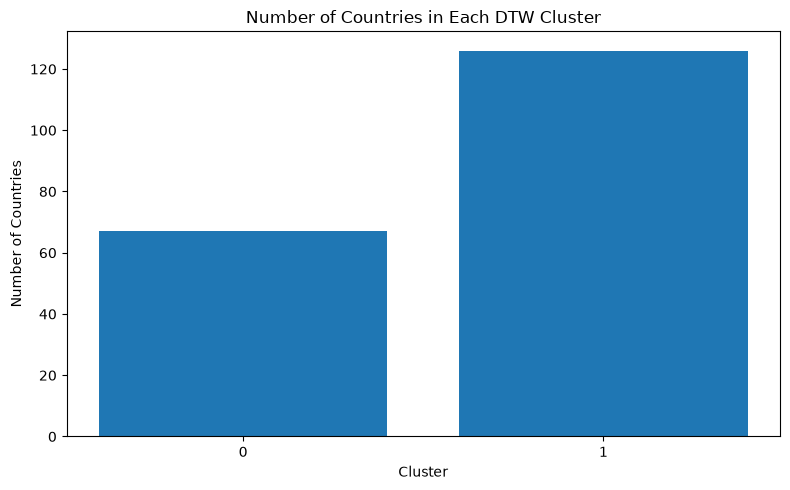

In [104]:
# ============================================
# 14. CLUSTER SIZE GRAPH
# ============================================

cluster_counts = (
    final_analysis["Cluster"]
    .value_counts()
    .sort_index()
)

plt.figure(figsize=(8, 5))

plt.bar(
    cluster_counts.index.astype(str),
    cluster_counts.values
)

plt.title("Number of Countries in Each DTW Cluster")
plt.xlabel("Cluster")
plt.ylabel("Number of Countries")

plt.tight_layout()
plt.show()

In [105]:
# ============================================
# TEST DIFFERENT NUMBERS OF CLUSTERS
# ============================================

k_results = []

for k in range(2, 7):

    print(f"\nTesting K = {k}")

    model_k = TimeSeriesKMeans(
        n_clusters=k,
        metric="dtw",
        max_iter=50,
        random_state=42,
        verbose=False
    )

    labels_k = model_k.fit_predict(X_fresh_scaled)

    # DTW distance matrix already calculated
    score_k = silhouette_score(
        fresh_dtw_distance_matrix,
        labels_k,
        metric="precomputed"
    )

    counts_k = pd.Series(labels_k).value_counts().sort_index()

    k_results.append({
        "K": k,
        "Silhouette Score": score_k,
        "Minimum Cluster Size": counts_k.min(),
        "Maximum Cluster Size": counts_k.max()
    })

k_evaluation = pd.DataFrame(k_results)

print("\nK EVALUATION")
display(k_evaluation.round(4))


Testing K = 2

Testing K = 3

Testing K = 4

Testing K = 5

Testing K = 6

K EVALUATION


,K,Silhouette Score,Minimum Cluster Size,Maximum Cluster Size
0,2,0.2758,67,126
1,3,0.1905,48,92
2,4,0.1568,1,84
3,5,0.1523,1,69
4,6,0.1164,1,52


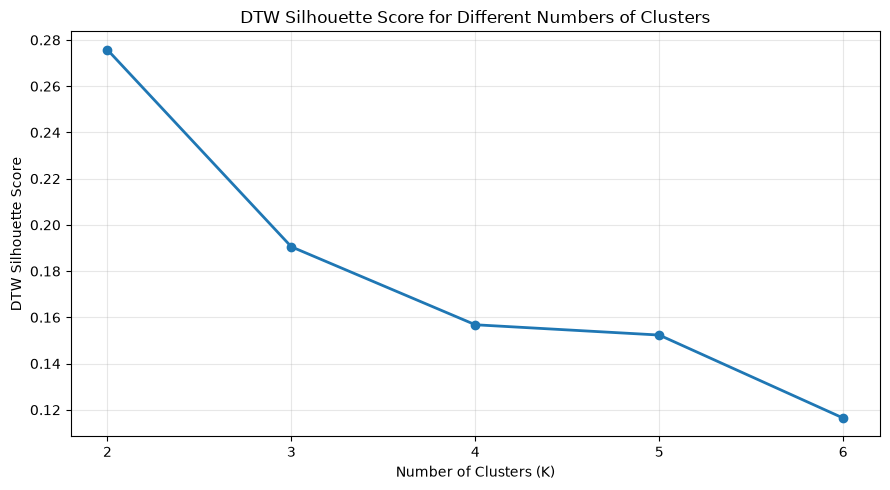

In [106]:
plt.figure(figsize=(9, 5))

plt.plot(
    k_evaluation["K"],
    k_evaluation["Silhouette Score"],
    marker="o",
    linewidth=2
)

plt.xlabel("Number of Clusters (K)")
plt.ylabel("DTW Silhouette Score")
plt.title("DTW Silhouette Score for Different Numbers of Clusters")

plt.xticks(k_evaluation["K"])
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [107]:
# ============================================
# CLUSTER CHARACTERISTICS
# ============================================

cluster_characteristics = []

for cluster in sorted(final_analysis["Cluster"].unique()):

    data = final_analysis[
        final_analysis["Cluster"] == cluster
    ]

    values = data[year_columns].to_numpy()

    cluster_characteristics.append({
        "Cluster": cluster,
        "Countries": len(data),
        "Average Inflation": values.mean(),
        "Median Inflation": np.median(values),
        "Minimum Inflation": values.min(),
        "Maximum Inflation": values.max(),
        "Standard Deviation": values.std()
    })

cluster_characteristics = pd.DataFrame(
    cluster_characteristics
)

display(
    cluster_characteristics.round(2)
)

,Cluster,Countries,Average Inflation,Median Inflation,Minimum Inflation,Maximum Inflation,Standard Deviation
0,0,67,136.63,7.81,-16.86,4734.91,561.39
1,1,126,21.60,4.41,-17.64,23773.13,322.29


In [109]:
# ============================================================
# REPRESENTATIVE COUNTRIES FOR EACH FINAL CLUSTER
# ============================================================

from tslearn.metrics import dtw
import numpy as np
import pandas as pd

representative_countries = []

# Loop through the actual cluster numbers
for cluster in sorted(np.unique(final_labels)):

    # Countries belonging to this cluster
    cluster_indices = np.where(final_labels == cluster)[0]

    # Cluster centroid
    centroid = final_model.cluster_centers_[cluster].ravel()

    distances = []

    # Calculate DTW distance of every country
    # from its cluster centroid
    for idx in cluster_indices:

        country_series = X_scaled[idx].ravel()

        distance = dtw(
            country_series,
            centroid
        )

        distances.append((idx, distance))

    # Sort from most representative to least representative
    distances.sort(key=lambda x: x[1])

    # Take 5 most representative countries
    for idx, distance in distances[:5]:

        representative_countries.append({
            "Cluster": cluster,
            "Country Name": countries.iloc[idx]["Country Name"],
            "Country Code": countries.iloc[idx]["Country Code"],
            "DTW Distance to Centroid": distance
        })

# Convert to DataFrame
representative_df = pd.DataFrame(
    representative_countries
)

print("============================================================")
print("REPRESENTATIVE COUNTRIES BY CLUSTER")
print("============================================================")

display(
    representative_df.round(4)
)

REPRESENTATIVE COUNTRIES BY CLUSTER


,Cluster,Country Name,Country Code,DTW Distance to Centroid
0,0,Saudi Arabia,SAU,2.9005
1,0,Chile,CHL,3.0020
2,0,Dominica,DMA,3.1121
3,0,Israel,ISR,3.1167
4,0,Oman,OMN,3.1359
5,1,Kyrgyz Republic,KGZ,1.9858
6,1,Romania,ROU,2.1603
7,1,"Yemen, Rep.",YEM,2.2427
8,1,Tajikistan,TJK,2.3299
9,1,Guyana,GUY,2.3423


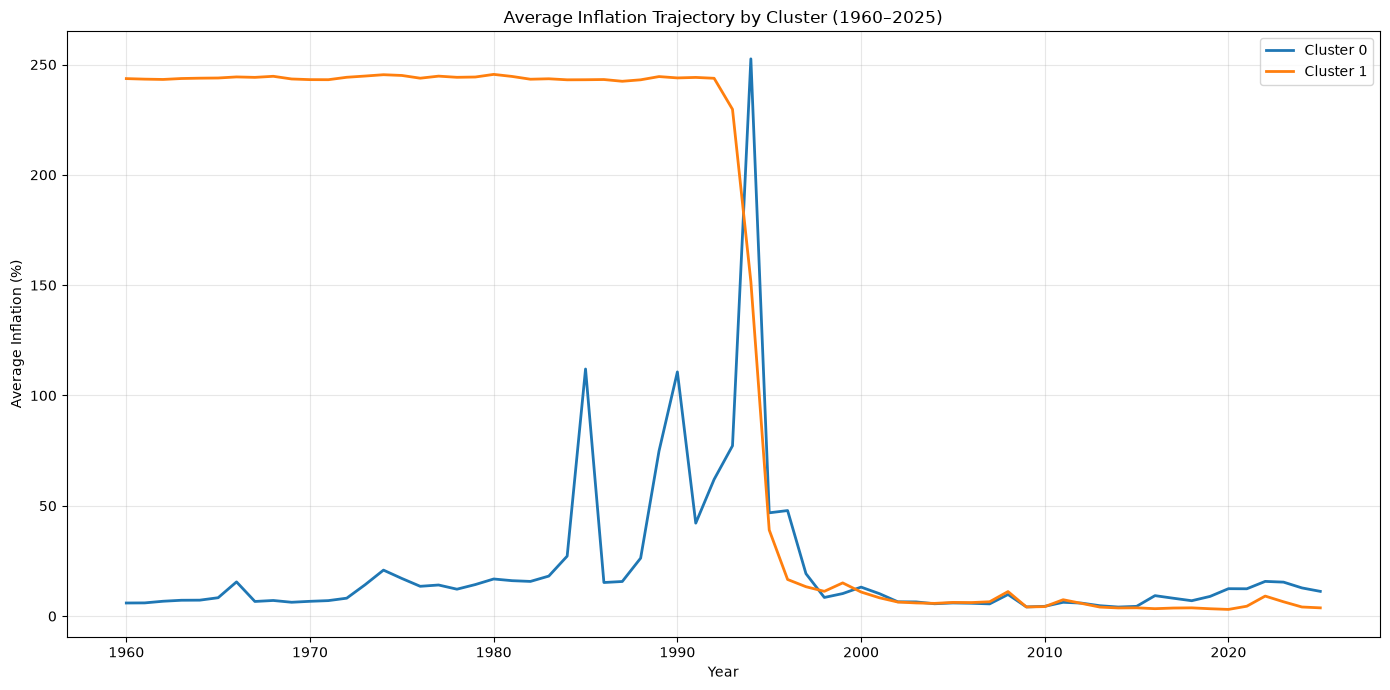

In [110]:
# ============================================================
# CLUSTER INFLATION TRAJECTORIES
# ============================================================

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# Create DataFrame containing final labels
plot_data = inflation_values.copy()

plot_data["Cluster"] = final_labels

# Calculate average inflation for each cluster
cluster_average = (
    plot_data
    .groupby("Cluster")[year_columns]
    .mean()
)

# Years as integers
years = [int(year) for year in year_columns]

# Plot
plt.figure(figsize=(14, 7))

for cluster in sorted(cluster_average.index):

    plt.plot(
        years,
        cluster_average.loc[cluster].values,
        linewidth=2,
        label=f"Cluster {cluster}"
    )

plt.xlabel("Year")
plt.ylabel("Average Inflation (%)")
plt.title("Average Inflation Trajectory by Cluster (1960–2025)")

plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [111]:
# Save final clustering results
final_clustering = countries[["Country Name", "Country Code"]].copy()
final_clustering["Cluster"] = final_labels

final_clustering.to_csv(
    "final_clustering_results.csv",
    index=False
)

# Save K evaluation
k_evaluation.to_csv(
    "k_evaluation_results.csv",
    index=False
)

# Save representative countries
representative_df.to_csv(
    "representative_countries.csv",
    index=False
)

print("Final clustering results saved successfully.")

Final clustering results saved successfully.
